In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import boxcox

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
# from category_encoders import BinaryEncoder
# from category_encoders import HashingEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text

from sklearn.ensemble import IsolationForest

from sklearn.decomposition import FastICA
from sklearn.manifold import Isomap
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import FactorAnalysis

pd.set_option("display.max_columns", None)

In [2]:
df = pd .read_csv("../datasets/alzheimers_disease_data.csv")
df.loc[:, ~df.columns.str.contains("doctorincharge|patientid")]
df.columns = df.columns.str.lower()
df

,patientid,age,gender,ethnicity,educationlevel,bmi,smoking,alcoholconsumption,physicalactivity,dietquality,sleepquality,familyhistoryalzheimers,cardiovasculardisease,diabetes,depression,headinjury,hypertension,systolicbp,diastolicbp,cholesteroltotal,cholesterolldl,cholesterolhdl,cholesteroltriglycerides,mmse,functionalassessment,memorycomplaints,behavioralproblems,adl,confusion,disorientation,personalitychanges,difficultycompletingtasks,forgetfulness,diagnosis,doctorincharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,XXXConfid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,6895,61,0,0,1,39.121757,0,1.561126,4.049964,6.555306,7.535540,0,0,0,0,0,0,122,101,280.476824,94.870490,60.943092,234.520123,1.201190,0.238667,0,0,4.492838,1,0,0,0,0,1,XXXConfid
2145,6896,75,0,0,2,17.857903,0,18.767261,1.360667,2.904662,8.555256,0,0,0,0,0,0,152,106,186.384436,95.410700,93.649735,367.986877,6.458060,8.687480,0,1,9.204952,0,0,0,0,0,1,XXXConfid
2146,6897,77,0,0,1,15.476479,0,4.594670,9.886002,8.120025,5.769464,0,0,0,0,0,0,115,118,237.024558,156.267294,99.678209,294.802338,17.011003,1.972137,0,0,5.036334,0,0,0,0,0,1,XXXConfid
2147,6898,78,1,3,1,15.299911,0,8.674505,6.354282,1.263427,8.322874,0,1,0,0,0,0,103,96,242.197192,52.482961,81.281111,145.253746,4.030491,5.173891,0,0,3.785399,0,0,0,0,1,1,XXXConfid


# EDA

In [3]:
df.shape

(2149, 35)

In [4]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Memory (MB): {df.memory_usage(deep=True).sum() / 1024 ** 2:.3f}")

Duplicate rows: 0
Memory (MB): 0.676


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patientid                  2149 non-null   int64  
 1   age                        2149 non-null   int64  
 2   gender                     2149 non-null   int64  
 3   ethnicity                  2149 non-null   int64  
 4   educationlevel             2149 non-null   int64  
 5   bmi                        2149 non-null   float64
 6   smoking                    2149 non-null   int64  
 7   alcoholconsumption         2149 non-null   float64
 8   physicalactivity           2149 non-null   float64
 9   dietquality                2149 non-null   float64
 10  sleepquality               2149 non-null   float64
 11  familyhistoryalzheimers    2149 non-null   int64  
 12  cardiovasculardisease      2149 non-null   int64  
 13  diabetes                   2149 non-null   int64  
 14  dep

In [6]:
summary = pd.DataFrame({"dtype": df.dtypes, "unique": df.nunique(), "missing": df.isna().sum()})
summary

,dtype,unique,missing
patientid,int64,2149,0
age,int64,31,0
gender,int64,2,0
ethnicity,int64,4,0
educationlevel,int64,4,0
bmi,float64,2149,0
smoking,int64,2,0
alcoholconsumption,float64,2149,0
physicalactivity,float64,2149,0
dietquality,float64,2149,0


In [7]:
df["diagnosis"].value_counts(normalize=True) * 100

diagnosis
0    64.634714
1    35.365286
Name: proportion, dtype: float64

In [8]:
age = df["age"]
df[age < 0]

,patientid,age,gender,ethnicity,educationlevel,bmi,smoking,alcoholconsumption,physicalactivity,dietquality,sleepquality,familyhistoryalzheimers,cardiovasculardisease,diabetes,depression,headinjury,hypertension,systolicbp,diastolicbp,cholesteroltotal,cholesterolldl,cholesterolhdl,cholesteroltriglycerides,mmse,functionalassessment,memorycomplaints,behavioralproblems,adl,confusion,disorientation,personalitychanges,difficultycompletingtasks,forgetfulness,diagnosis,doctorincharge


In [9]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numeric Columns")
print(numeric_columns)

print()

print("Categorical Columns")
print(categorical_columns)

Numeric Columns
['patientid', 'age', 'gender', 'ethnicity', 'educationlevel', 'bmi', 'smoking', 'alcoholconsumption', 'physicalactivity', 'dietquality', 'sleepquality', 'familyhistoryalzheimers', 'cardiovasculardisease', 'diabetes', 'depression', 'headinjury', 'hypertension', 'systolicbp', 'diastolicbp', 'cholesteroltotal', 'cholesterolldl', 'cholesterolhdl', 'cholesteroltriglycerides', 'mmse', 'functionalassessment', 'memorycomplaints', 'behavioralproblems', 'adl', 'confusion', 'disorientation', 'personalitychanges', 'difficultycompletingtasks', 'forgetfulness', 'diagnosis']

Categorical Columns
['doctorincharge']


C:\Users\Sorena Pardaz\AppData\Local\Temp\ipykernel_12316\1010696667.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns.tolist()


In [10]:
binary_features = []
for col in df.columns:
    if df[col].nunique()==2:
        binary_features.append(col)
binary_features

['gender',
 'smoking',
 'familyhistoryalzheimers',
 'cardiovasculardisease',
 'diabetes',
 'depression',
 'headinjury',
 'hypertension',
 'memorycomplaints',
 'behavioralproblems',
 'confusion',
 'disorientation',
 'personalitychanges',
 'difficultycompletingtasks',
 'forgetfulness',
 'diagnosis']

In [11]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
patientid,2149.0,5825.000000,620.507185,4751.000000,5288.000000,5825.000000,6362.000000,6899.000000
age,2149.0,74.908795,8.990221,60.000000,67.000000,75.000000,83.000000,90.000000
gender,2149.0,0.506282,0.500077,0.000000,0.000000,1.000000,1.000000,1.000000
ethnicity,2149.0,0.697534,0.996128,0.000000,0.000000,0.000000,1.000000,3.000000
educationlevel,2149.0,1.286645,0.904527,0.000000,1.000000,1.000000,2.000000,3.000000
bmi,2149.0,27.655697,7.217438,15.008851,21.611408,27.823924,33.869778,39.992767
smoking,2149.0,0.288506,0.453173,0.000000,0.000000,0.000000,1.000000,1.000000
alcoholconsumption,2149.0,10.039442,5.757910,0.002003,5.139810,9.934412,15.157931,19.989293
physicalactivity,2149.0,4.920202,2.857191,0.003616,2.570626,4.766424,7.427899,9.987429
dietquality,2149.0,4.993138,2.909055,0.009385,2.458455,5.076087,7.558625,9.998346


In [12]:
for col in numeric_columns:

    Q1 = df[col].quantile(.25)
    Q3 = df[col].quantile(.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(col, len(outliers))

patientid 0
age 0
gender 0
ethnicity 211
educationlevel 0
bmi 0
smoking 0
alcoholconsumption 0
physicalactivity 0
dietquality 0
sleepquality 0
familyhistoryalzheimers 0
cardiovasculardisease 310
diabetes 324
depression 431
headinjury 199
hypertension 320
systolicbp 0
diastolicbp 0
cholesteroltotal 0
cholesterolldl 0
cholesterolhdl 0
cholesteroltriglycerides 0
mmse 0
functionalassessment 0
memorycomplaints 447
behavioralproblems 337
adl 0
confusion 441
disorientation 340
personalitychanges 324
difficultycompletingtasks 341
forgetfulness 0
diagnosis 0


C:\Users\Sorena Pardaz\AppData\Local\Temp\ipykernel_12316\2119867835.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="diagnosis", data=df, palette="Set2", ax=axes[0])
C:\Users\Sorena Pardaz\AppData\Local\Temp\ipykernel_12316\2119867835.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Yes", "No"])


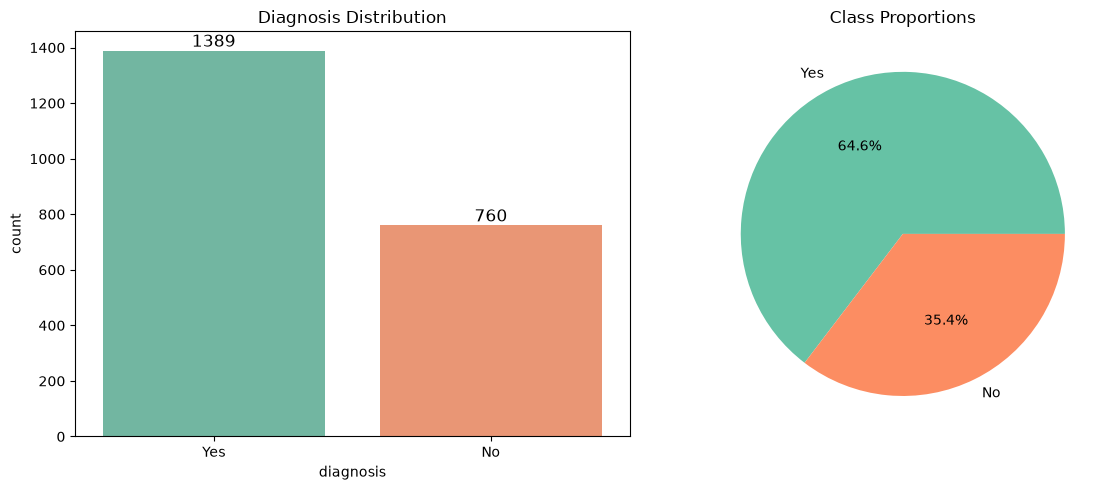

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x="diagnosis", data=df, palette="Set2", ax=axes[0])
axes[0].set_xticklabels(["Yes", "No"])
axes[0].set_title("Diagnosis Distribution")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}",(p.get_x() + p.get_width() / 2., p.get_height()), ha="center", va="bottom", fontsize=12)

df["diagnosis"].value_counts().plot.pie(labels=["Yes", "No"], autopct="%1.1f%%", colors=["#66c2a5", "#fc8d62"], ax=axes[1])
axes[1].set_ylabel("")
axes[1].set_title("Class Proportions")

plt.tight_layout()
plt.show()

In [14]:
numeric_columns.remove("patientid")

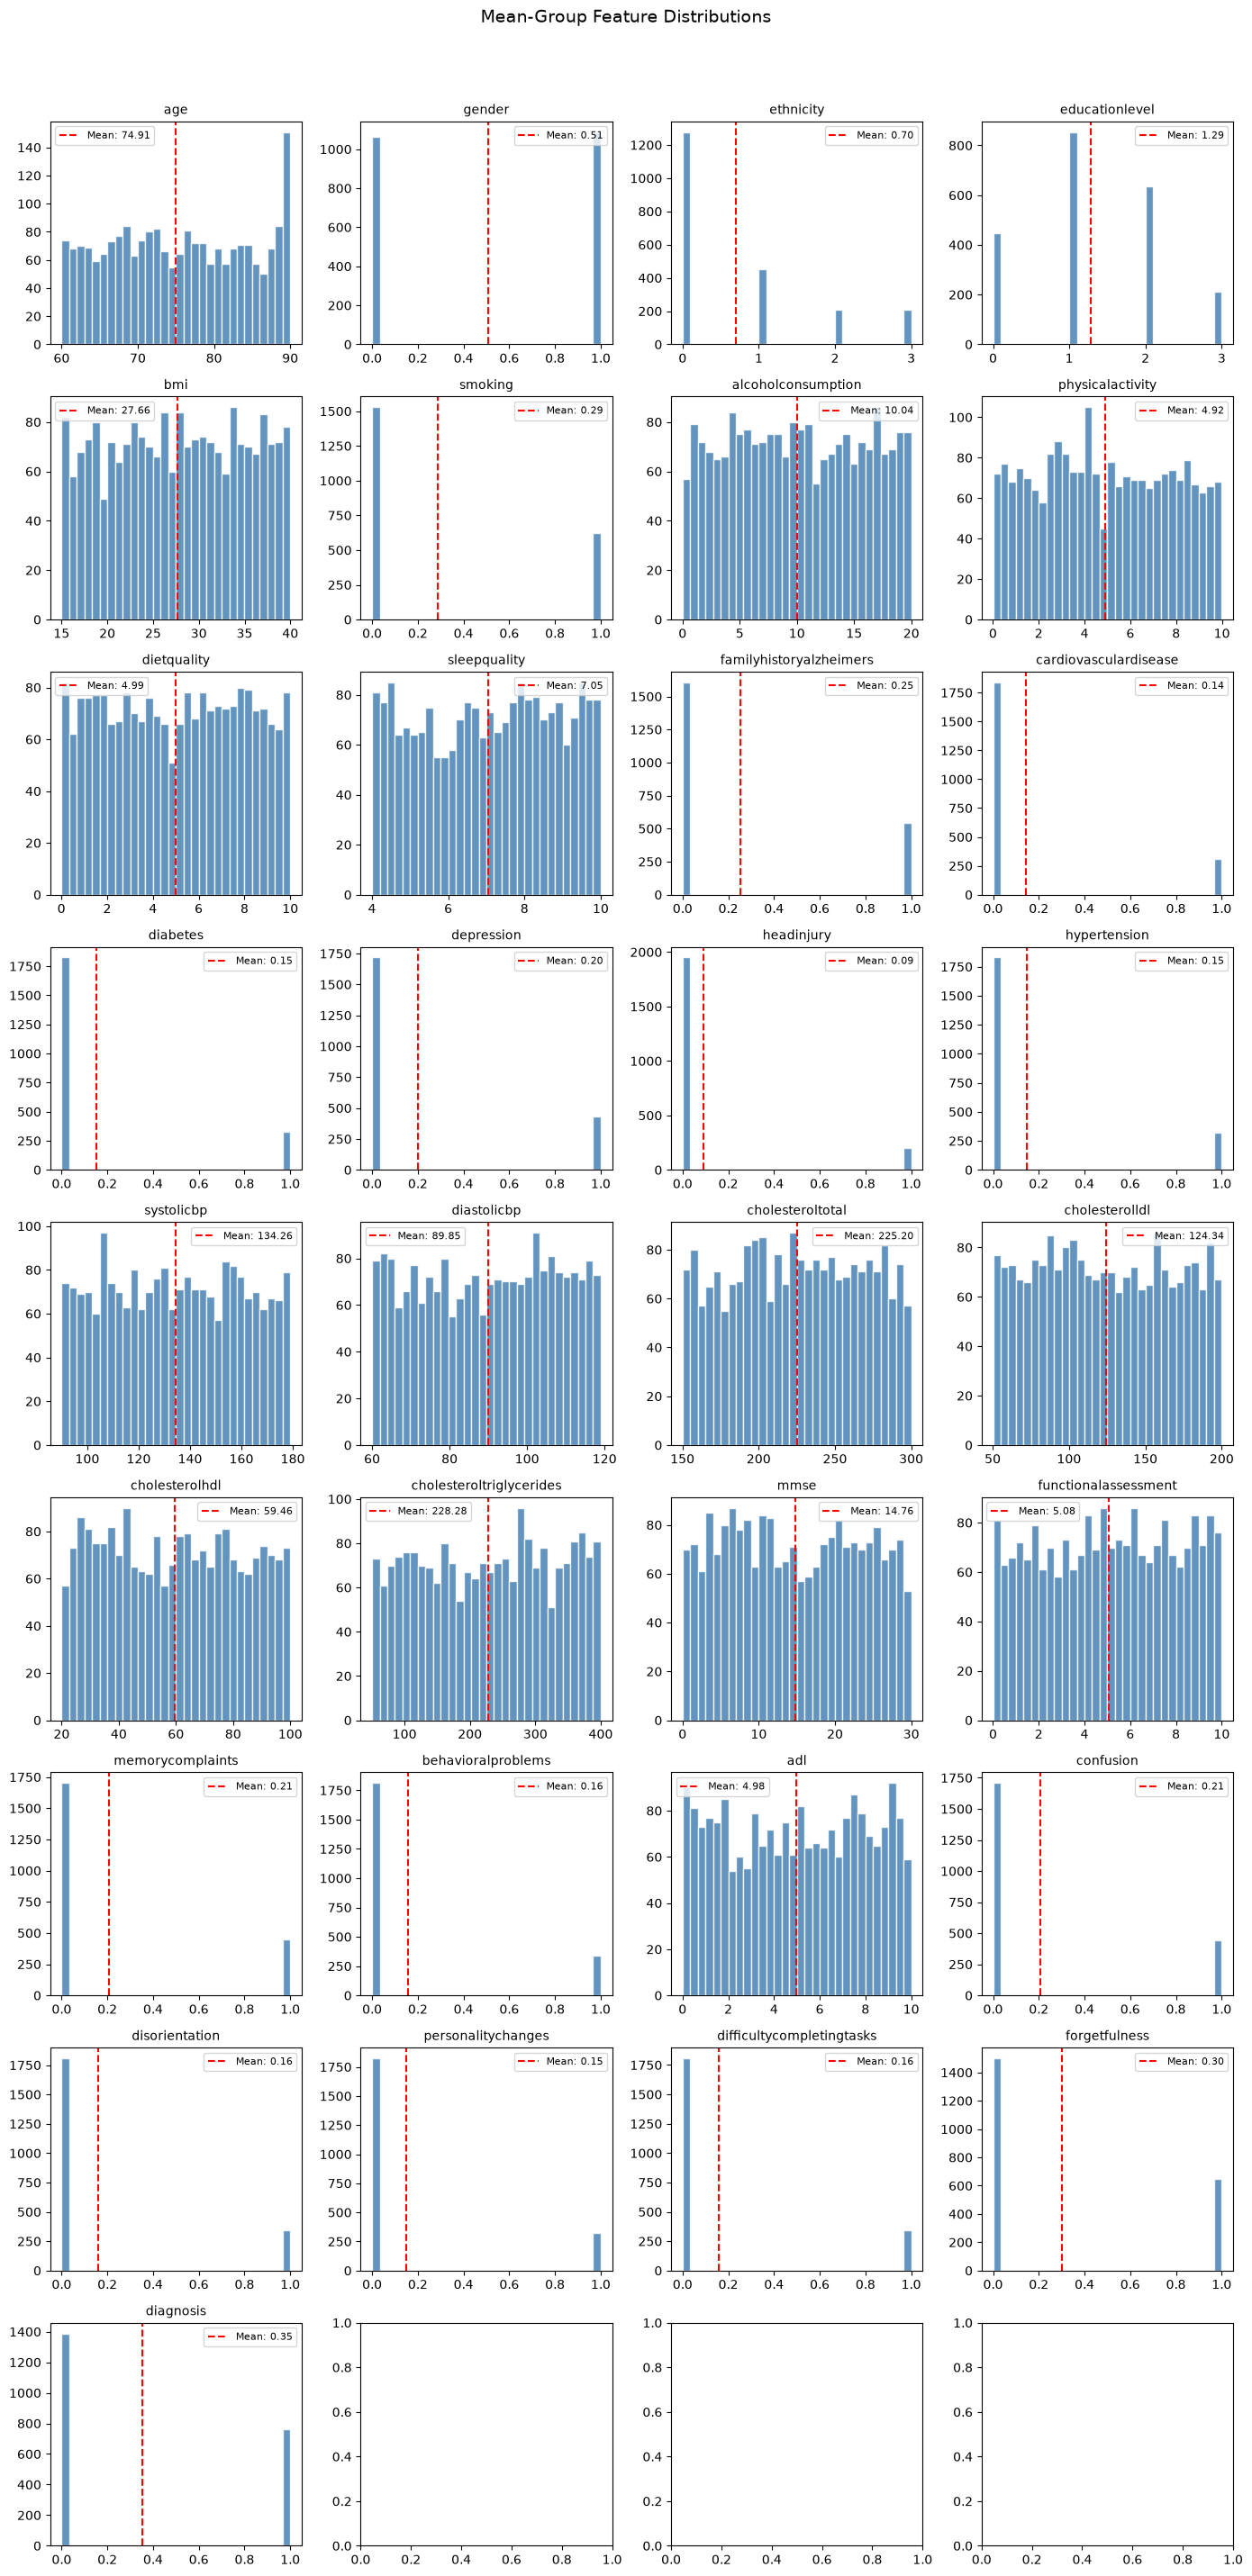

In [15]:
mean_features = [f"{f}" for f in numeric_columns]

fig, axes = plt.subplots(9, 4, figsize=(14, 28))
axes = axes.flatten()
for i, col in enumerate(mean_features):
    axes[i].hist(df[col], bins=30, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean: {df[col].mean():.2f}")
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)
plt.suptitle("Mean-Group Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

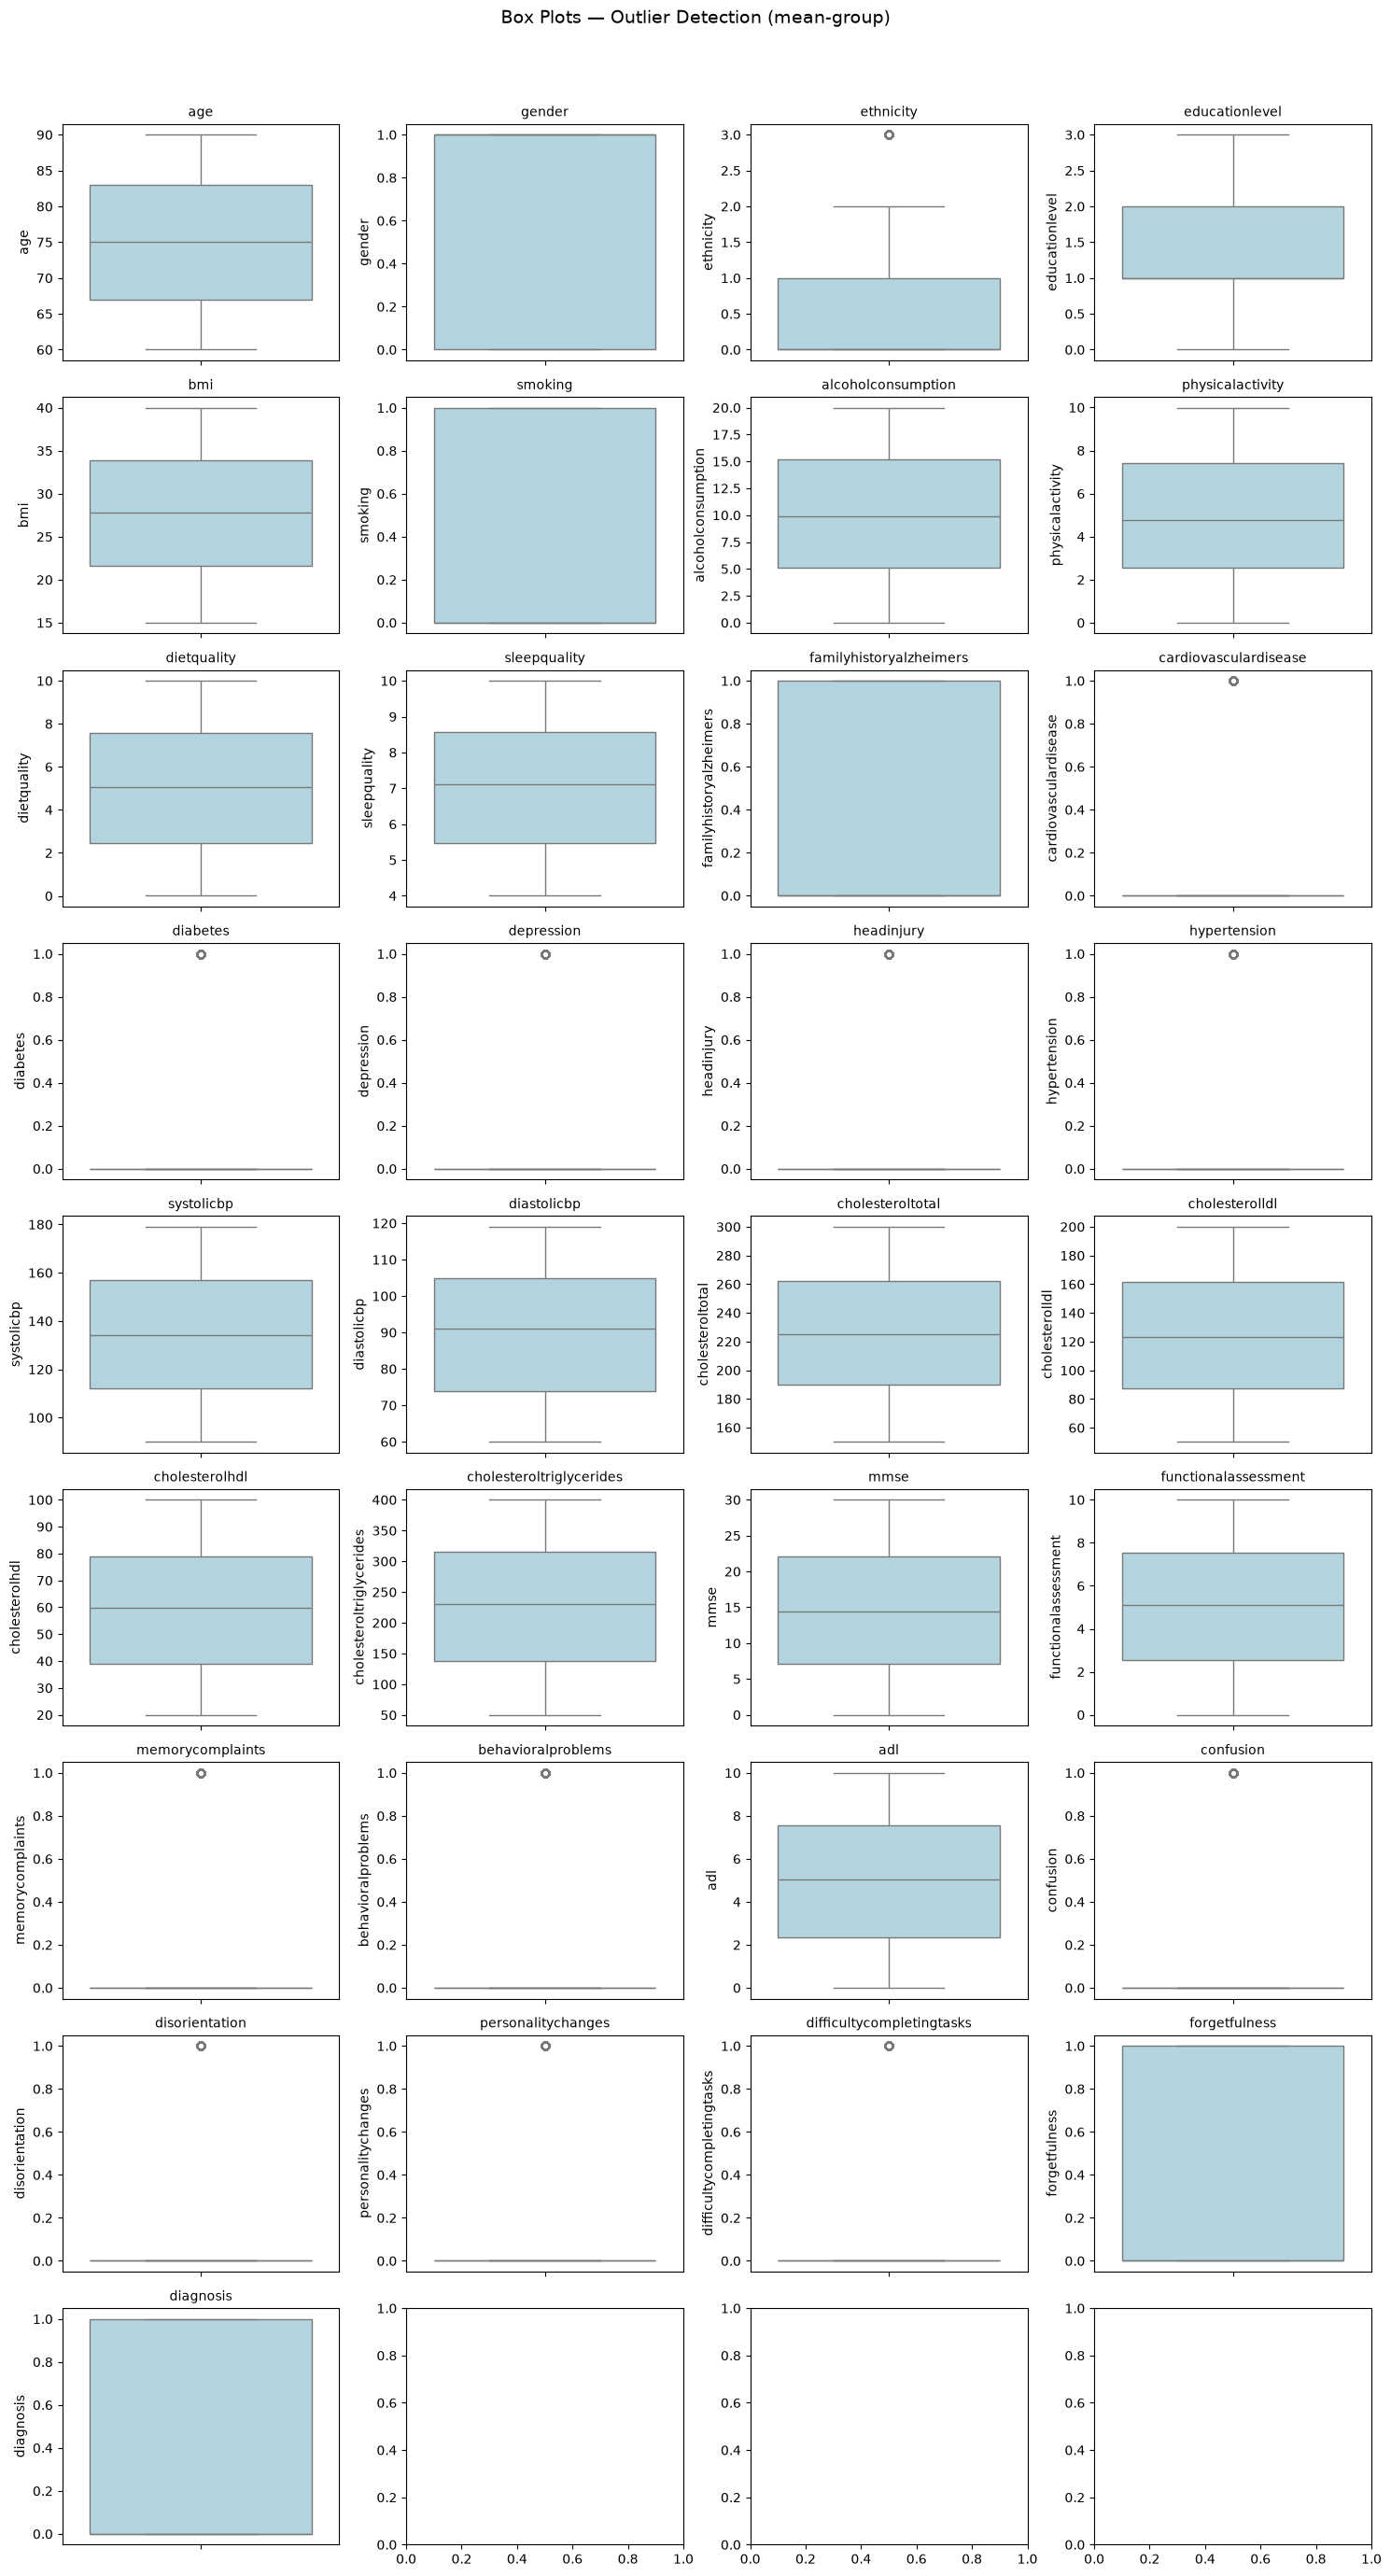

In [16]:
fig, axes = plt.subplots(9, 4, figsize=(15, 27))
axes = axes.flatten()
for i, col in enumerate(mean_features):
    sns.boxplot(y=df[col], ax=axes[i], color="lightblue")
    axes[i].set_title(col, fontsize=10)
plt.suptitle("Box Plots — Outlier Detection (mean-group)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# sns.pairplot(data=df[numeric_columns])

In [18]:
summary = df.describe().T
summary["median"] = df.median(numeric_only=True)
summary["variance"] = df.var(numeric_only=True)
summary["skewness"] = df.skew(numeric_only=True)
summary["kurtosis"] = df.kurt(numeric_only=True)
summary

,count,mean,std,min,25%,50%,75%,max,median,variance,skewness,kurtosis
patientid,2149.0,5825.000000,620.507185,4751.000000,5288.000000,5825.000000,6362.000000,6899.000000,5825.000000,385029.166667,0.000000,-1.200000
age,2149.0,74.908795,8.990221,60.000000,67.000000,75.000000,83.000000,90.000000,75.000000,80.824080,0.045964,-1.189214
gender,2149.0,0.506282,0.500077,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.250077,-0.025148,-2.001231
ethnicity,2149.0,0.697534,0.996128,0.000000,0.000000,0.000000,1.000000,3.000000,0.000000,0.992270,1.230215,0.233889
educationlevel,2149.0,1.286645,0.904527,0.000000,1.000000,1.000000,2.000000,3.000000,1.000000,0.818169,0.209118,-0.752721
bmi,2149.0,27.655697,7.217438,15.008851,21.611408,27.823924,33.869778,39.992767,27.823924,52.091413,-0.026715,-1.184508
smoking,2149.0,0.288506,0.453173,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.205366,0.934260,-1.128210
alcoholconsumption,2149.0,10.039442,5.757910,0.002003,5.139810,9.934412,15.157931,19.989293,9.934412,33.153531,0.018415,-1.202876
physicalactivity,2149.0,4.920202,2.857191,0.003616,2.570626,4.766424,7.427899,9.987429,4.766424,8.163541,0.044973,-1.179196
dietquality,2149.0,4.993138,2.909055,0.009385,2.458455,5.076087,7.558625,9.998346,5.076087,8.462601,-0.012058,-1.228962


In [19]:
pearson_corr = df.corr("pearson",numeric_only=True)
pearson_corr

,patientid,age,gender,ethnicity,educationlevel,bmi,smoking,alcoholconsumption,physicalactivity,dietquality,sleepquality,familyhistoryalzheimers,cardiovasculardisease,diabetes,depression,headinjury,hypertension,systolicbp,diastolicbp,cholesteroltotal,cholesterolldl,cholesterolhdl,cholesteroltriglycerides,mmse,functionalassessment,memorycomplaints,behavioralproblems,adl,confusion,disorientation,personalitychanges,difficultycompletingtasks,forgetfulness,diagnosis
patientid,1.000000,0.002947,-0.043665,-0.007608,-0.001729,-0.034228,0.021907,-0.020733,-0.011424,-0.018490,-0.026069,0.002187,0.017675,-0.003910,0.023736,-0.025100,-0.012668,-0.021153,-0.007634,0.004426,-0.024788,-0.010773,0.010452,-0.006777,0.025033,0.005748,-0.033700,-0.019787,0.004430,0.010772,-0.011987,0.029727,0.001448,0.041019
age,0.002947,1.000000,0.028708,0.027745,-0.060560,-0.015677,0.020060,0.007323,-0.010249,-0.023386,0.049139,-0.018784,-0.015284,-0.005708,-0.008752,-0.040337,0.003954,-0.005324,-0.004462,0.000392,0.003588,0.006803,-0.003062,-0.004235,0.005508,0.012343,0.038973,-0.038658,0.009002,0.027523,-0.009470,0.013900,-0.019279,-0.005488
gender,-0.043665,0.028708,1.000000,-0.003660,-0.007070,0.005928,0.016650,0.004330,-0.035795,0.010942,0.007310,0.018421,0.034577,-0.018300,0.018113,0.004013,-0.002641,0.011657,-0.026059,-0.009568,0.016271,-0.005846,-0.012427,0.025330,0.033324,0.003880,0.006099,0.003865,-0.030583,0.017506,0.025919,-0.001636,-0.028537,-0.020975
ethnicity,-0.007608,0.027745,-0.003660,1.000000,0.026516,-0.003176,0.031485,0.008363,0.020498,-0.018184,0.029304,0.022526,0.002347,-0.019588,-0.005411,-0.009364,0.012848,-0.027086,0.010310,-0.011757,0.007907,-0.021828,-0.007173,-0.012504,-0.004704,0.003687,-0.019363,0.010475,0.022431,-0.018132,-0.030035,0.019363,-0.034619,-0.014782
educationlevel,-0.001729,-0.060560,-0.007070,0.026516,1.000000,-0.023514,-0.009904,-0.012646,-0.016703,0.017412,0.020248,0.032748,0.007528,0.003059,0.027573,-0.008951,-0.016950,-0.016782,-0.002553,-0.041598,0.050504,-0.008125,-0.025763,0.026090,0.020269,-0.000165,0.010473,0.031934,-0.008168,-0.017568,-0.019950,0.013033,-0.008685,-0.043966
bmi,-0.034228,-0.015677,0.005928,-0.003176,-0.023514,1.000000,0.020437,-0.008997,0.000742,0.019922,-0.005975,0.006446,-0.005467,-0.008980,-0.012507,0.016288,0.004928,-0.019275,-0.002524,0.001082,0.023684,0.038605,-0.018001,-0.003477,-0.030501,0.029293,0.035276,-0.009788,-0.015859,-0.031840,-0.015901,-0.039400,0.071131,0.026343
smoking,0.021907,0.020060,0.016650,0.031485,-0.009904,0.020437,1.000000,0.008363,0.010760,-0.002048,-0.001145,-0.045811,0.027955,-0.035810,-0.039363,-0.019178,-0.021124,-0.024116,-0.014112,-0.010907,-0.007393,-0.025567,-0.021058,0.002139,-0.031879,0.020339,-0.014763,-0.029233,0.004498,-0.028403,-0.009977,0.001741,0.018011,-0.004865
alcoholconsumption,-0.020733,0.007323,0.004330,0.008363,-0.012646,-0.008997,0.008363,1.000000,0.021696,0.020117,-0.003873,-0.003707,-0.023632,0.000073,0.008867,-0.008301,-0.006010,-0.030070,-0.008909,-0.033944,-0.017042,-0.001925,0.023362,-0.011424,-0.016483,-0.029418,0.013657,-0.008250,-0.032798,0.015521,0.019117,-0.002712,-0.024121,-0.007618
physicalactivity,-0.011424,-0.010249,-0.035795,0.020498,-0.016703,0.000742,0.010760,0.021696,1.000000,0.011085,-0.001823,-0.014106,0.003976,0.029880,-0.013533,0.025780,0.022081,-0.004811,-0.010555,0.014335,0.017789,-0.001993,0.027416,-0.008342,-0.002419,0.008709,-0.014253,-0.013324,-0.009397,-0.020407,-0.013629,0.031169,0.009837,0.005945
dietquality,-0.018490,-0.023386,0.010942,-0.018184,0.017412,0.019922,-0.002048,0.020117,0.011085,1.000000,0.051295,-0.011261,-0.015220,0.009192,-0.002516,-0.008163,-0.043628,0.006031,0.009539,-0.016790,-0.023698,-0.008659,0.034734,0.021636,-0.009700,0.012537,-0.014033,-0.007888,0.002628,-0.026271,0.029087,0.045737,0.006175,0.008506


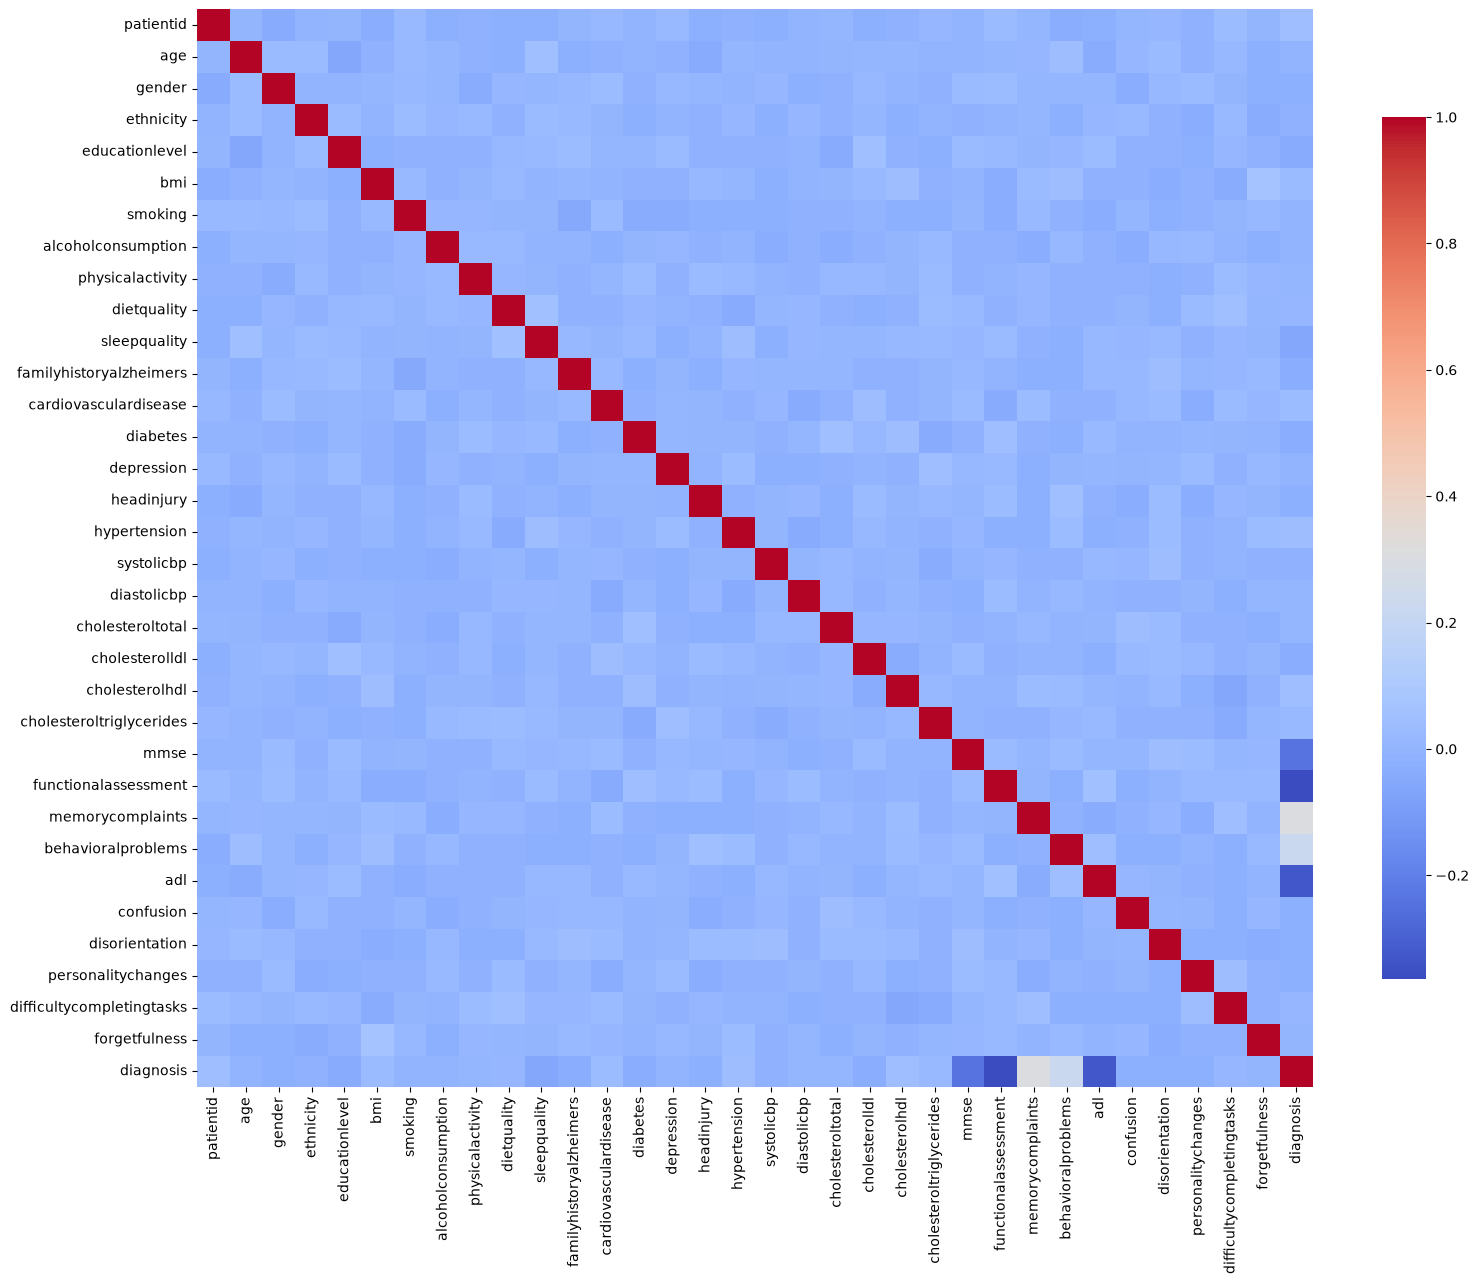

In [20]:
plt.figure(figsize=(18,14))
sns.heatmap(pearson_corr, cmap="coolwarm", cbar_kws={"shrink": 0.8})
plt.show()

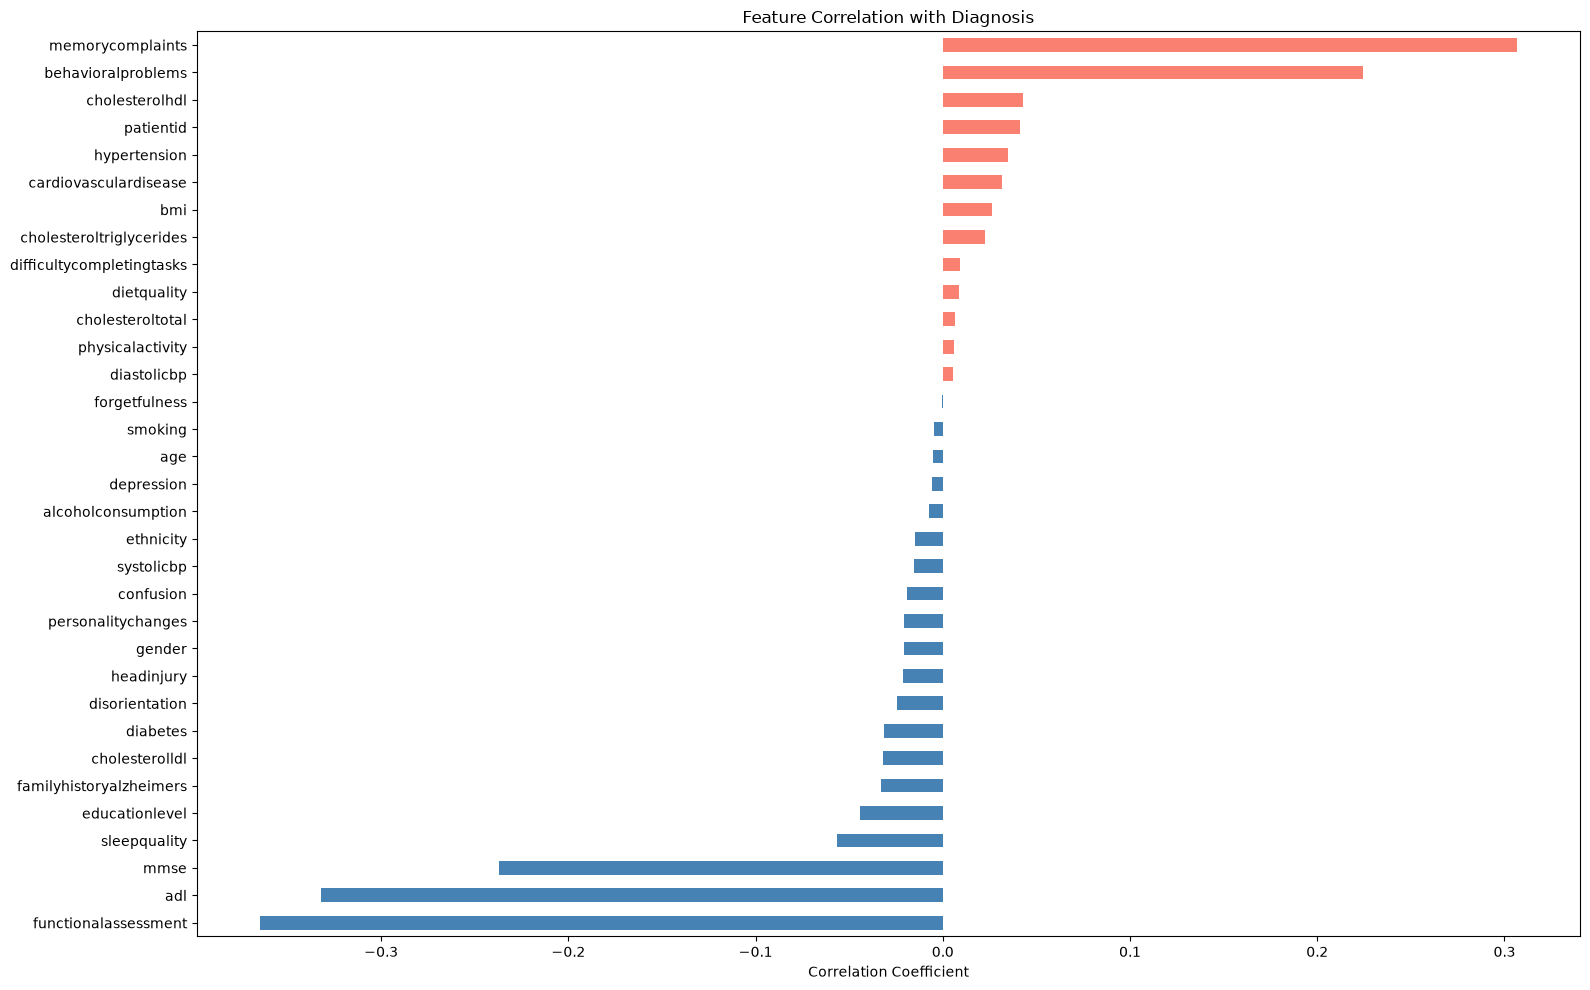

Top 10 features by correlation with diagnosis:
memorycomplaints             0.307
behavioralproblems           0.224
cholesterolhdl               0.043
patientid                    0.041
hypertension                 0.035
cardiovasculardisease        0.031
bmi                          0.026
cholesteroltriglycerides     0.023
difficultycompletingtasks    0.009
dietquality                  0.009
Name: diagnosis, dtype: float64


In [21]:
target_corr = df.drop(columns=["doctorincharge"]).corr()["diagnosis"].drop("diagnosis").sort_values(ascending=False)

plt.figure(figsize=(16, 10))
target_corr.plot(kind="barh", color=["salmon" if x > 0 else "steelblue" for x in target_corr])
plt.title("Feature Correlation with Diagnosis")
plt.xlabel("Correlation Coefficient")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 features by correlation with diagnosis:")
print(target_corr.head(10).round(3))

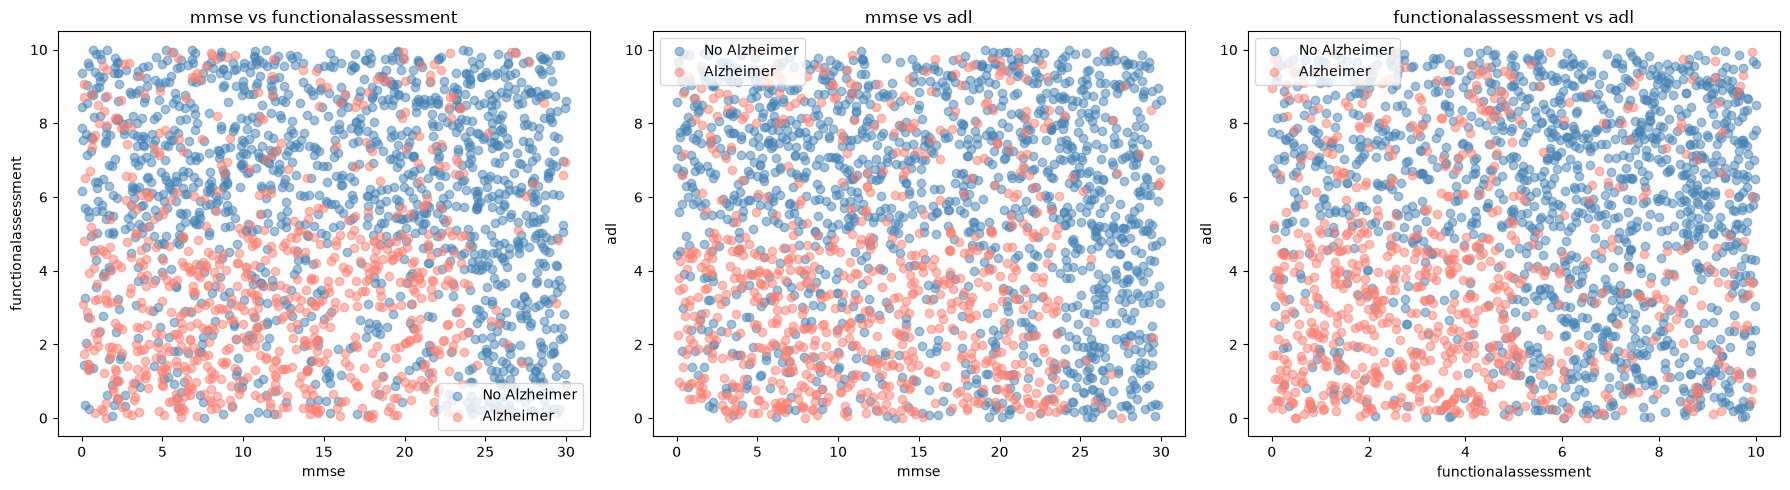

In [22]:
pairs = [
    ("mmse", "functionalassessment"),
    ("mmse", "adl"),
    ("functionalassessment", "adl"),
]

fig, axes = plt.subplots(1, len(pairs), figsize=(18,5))

for i, (x_feature, y_feature) in enumerate(pairs):

    for diag, color, label in [(0, "steelblue", "No Alzheimer"), (1, "salmon", "Alzheimer")]:
        subset = df[df["diagnosis"] == diag]
        axes[i].scatter(subset[x_feature], subset[y_feature], c=color, alpha=0.5, label=label)
    axes[i].set_xlabel(x_feature)
    axes[i].set_ylabel(y_feature)
    axes[i].set_title(f"{x_feature} vs {y_feature}")
    axes[i].legend()
plt.tight_layout()
plt.show()

# 2. Encoding Categorical Variables

Most categorical features in this dataset are already encoded as numeric values (e.g., binary variables encoded as 0/1 and ordinal variables represented by integer levels). Therefore, no additional encoding is required before training most machine learning models.

The examples in this section are provided **for demonstration purposes only** to illustrate common encoding techniques and when they should be applied to other datasets.

For this dataset:

* `ethnicity` is a nominal categorical feature and could be one-hot encoded if the numeric values represent category labels rather than meaningful numeric values.
* `educationlevel` appears to be an ordinal feature and is already encoded as integer levels, assuming the values preserve the correct ordering.
* Most remaining categorical features are binary (0/1) and do not require further encoding.
* `patientid` and `doctorincharge` are identifier-like features and should typically be removed rather than encoded.


In [23]:
binary_features = [
    "smoking",
    "alcoholconsumption",
    "familyhistoryalzheimers",
    "cardiovasculardisease",
    "diabetes",
    "depression",
    "headinjury",
    "hypertension",
    "memorycomplaints",
    "behavioralproblems",
    "confusion",
    "disorientation",
    "personalitychanges",
    "difficultycompletingtasks",
    "forgetfulness"
]

### **2.1 One-Hot Encoding :** One-Hot Encoding converts each category into a separate binary (0/1) feature Instead of assigning an integer to each category, it creates one column per category.

### When should be used? 
- Categories have no natural order
- Number of unique categories is relatively small

Typical instances : (Gender, Country, Ethnicity, City (small number), Product Category)

In [24]:

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded = encoder.fit_transform(df[["ethnicity"]])


### **2.2 Ordinal Encoding :** Ordinal Encoding assigns an integer value to each category while preserving their natural order.

When to use? 

Categories have a meaningful order
- Education Level
- Customer Satisfaction
- T-Shirt Size
- Risk Level

In [25]:

encoder = OrdinalEncoder()
df["educationlevel"] = encoder.fit_transform(df[["educationlevel"]])

### **2.3 Label Encoding :** Label Encoding converts each category into an integer, unlike Ordinal Encoding, Label Encoding does not imply that these numbers represent a meaningful order.

when shall we use it? 
- Spam / Not Spam
- Disease / Healthy
- Positive / Negative

In [26]:

encoder = LabelEncoder()
df["diagnosis"] = encoder.fit_transform(df["diagnosis"])

### **2.4 Binary Encoding :** Binary Encoding first converts each category into an integer, then converts that integer into binary digits. Each binary digit becomes a new feature, we exploit it when we have medium-cardinality categorical variables typically 20–200 categories.

In [27]:

# encoder = BinaryEncoder(cols=["hospital"])
# encoded_df = encoder.fit_transform(df)

### **2.5 Hash Encoding :** Hash Encoding maps each category to a fixed number of columns using a hash function The number of output columns is chosen in advance.

when to use?   Very high-cardinality features
- User IDs
- Search Queries
- URLs
- Large text categories

In [28]:
# encoder = HashingEncoder(cols=["user_id"], n_components=8)
# encoded_df = encoder.fit_transform(df)

### **2.6 Frequency Encoding :** Each category is replaced by its frequency (or proportion) in the dataset.

In [29]:
freq = df["ethnicity"].value_counts()
df_freqenc = df.copy()
df_freqenc["ethnicity_freq"] = (df_freqenc["ethnicity"].map(freq))

In [30]:
frequency = df["doctorincharge"].value_counts()
df["doctor_frequency"] = df["doctorincharge"].map(frequency)         # since we lack of columns for encoding we use this.   NOT recommencded

### **2.7 Target Encoding :** Each category is replaced with the average value of the target variable. 
When to use? 

High-cardinality categorical variables
- Linear models
- Gradient Boosting
- CatBoost-like approaches

**NOTE:** Never compute target encoding on the full dataset before train/test splitting. Use out-of-fold encoding or cross-validation to avoid data leakage.

In [31]:
target_mean = (df.groupby("doctorincharge")["diagnosis"].mean())
df["doctor_target"] = df["doctorincharge"].map(target_mean)

### **2.8 Rare Category Grouping :** Rare categories are grouped into a single category such as "Other" we use it when categories have very low frequencies

In [32]:
counts = df["ethnicity"].value_counts()
rare_categories = counts[counts < 20].index
df["ethnicity"] = df["ethnicity"].replace(rare_categories, "Other")

In [33]:
risk_features = [
"smoking",
"diabetes",
"hypertension",
"cardiovasculardisease",
"depression"
]
df["risk_count"] = (df[risk_features].sum(axis=1))
df

,patientid,age,gender,ethnicity,educationlevel,bmi,smoking,alcoholconsumption,physicalactivity,dietquality,sleepquality,familyhistoryalzheimers,cardiovasculardisease,diabetes,depression,headinjury,hypertension,systolicbp,diastolicbp,cholesteroltotal,cholesterolldl,cholesterolhdl,cholesteroltriglycerides,mmse,functionalassessment,memorycomplaints,behavioralproblems,adl,confusion,disorientation,personalitychanges,difficultycompletingtasks,forgetfulness,diagnosis,doctorincharge,doctor_frequency,doctor_target,risk_count
0,4751,73,0,0,2.0,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,XXXConfid,2149,0.353653,2
1,4752,89,0,0,0.0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,XXXConfid,2149,0.353653,0
2,4753,73,0,3,1.0,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,XXXConfid,2149,0.353653,0
3,4754,74,1,0,1.0,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,XXXConfid,2149,0.353653,1
4,4755,89,0,0,0.0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,XXXConfid,2149,0.353653,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,6895,61,0,0,1.0,39.121757,0,1.561126,4.049964,6.555306,7.535540,0,0,0,0,0,0,122,101,280.476824,94.870490,60.943092,234.520123,1.201190,0.238667,0,0,4.492838,1,0,0,0,0,1,XXXConfid,2149,0.353653,0
2145,6896,75,0,0,2.0,17.857903,0,18.767261,1.360667,2.904662,8.555256,0,0,0,0,0,0,152,106,186.384436,95.410700,93.649735,367.986877,6.458060,8.687480,0,1,9.204952,0,0,0,0,0,1,XXXConfid,2149,0.353653,0
2146,6897,77,0,0,1.0,15.476479,0,4.594670,9.886002,8.120025,5.769464,0,0,0,0,0,0,115,118,237.024558,156.267294,99.678209,294.802338,17.011003,1.972137,0,0,5.036334,0,0,0,0,0,1,XXXConfid,2149,0.353653,0
2147,6898,78,1,3,1.0,15.299911,0,8.674505,6.354282,1.263427,8.322874,0,1,0,0,0,0,103,96,242.197192,52.482961,81.281111,145.253746,4.030491,5.173891,0,0,3.785399,0,0,0,0,1,1,XXXConfid,2149,0.353653,1


In [34]:
binary_features = ["gender", "smoking", "diabetes", "hypertension", "depression", "memorycomplaints"]
for feature in binary_features:
    if feature in numeric_columns:
        numeric_columns.remove(feature)

# 3. Scaling and Normalization
Scaling is the process of transforming numerical features so that they are on a comparable scale. It does **not** change the relationship between observations; instead, it changes the magnitude of feature values.
Many machine learning algorithms (such as KNN, SVM, Neural Networks, PCA, and Logistic Regression) are sensitive to feature scales because they rely on distances or gradient-based optimization.

In [35]:
for col in df.columns:
    print(col ,df[col].nunique())

patientid 2149
age 31
gender 2
ethnicity 4
educationlevel 4
bmi 2149
smoking 2
alcoholconsumption 2149
physicalactivity 2149
dietquality 2149
sleepquality 2149
familyhistoryalzheimers 2
cardiovasculardisease 2
diabetes 2
depression 2
headinjury 2
hypertension 2
systolicbp 90
diastolicbp 60
cholesteroltotal 2149
cholesterolldl 2149
cholesterolhdl 2149
cholesteroltriglycerides 2149
mmse 2149
functionalassessment 2149
memorycomplaints 2
behavioralproblems 2
adl 2149
confusion 2
disorientation 2
personalitychanges 2
difficultycompletingtasks 2
forgetfulness 2
diagnosis 2
doctorincharge 1
doctor_frequency 1
doctor_target 1
risk_count 6


In [36]:
numeric_column = df.select_dtypes(include=np.number).columns.tolist()
binary_columns = [col for col in numeric_column if df[col].nunique() <= 6]
continuous_numeric_columns = [col for col in numeric_column if col not in binary_columns]
continuous_numeric_columns

['patientid',
 'age',
 'bmi',
 'alcoholconsumption',
 'physicalactivity',
 'dietquality',
 'sleepquality',
 'systolicbp',
 'diastolicbp',
 'cholesteroltotal',
 'cholesterolldl',
 'cholesterolhdl',
 'cholesteroltriglycerides',
 'mmse',
 'functionalassessment',
 'adl']

In [37]:
X_num = df[continuous_numeric_columns]
X_num.head()

,patientid,age,bmi,alcoholconsumption,physicalactivity,dietquality,sleepquality,systolicbp,diastolicbp,cholesteroltotal,cholesterolldl,cholesterolhdl,cholesteroltriglycerides,mmse,functionalassessment,adl
0,4751,73,22.927749,13.297218,6.327112,1.347214,9.025679,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,1.725883
1,4752,89,26.827681,4.542524,7.619885,0.518767,7.151293,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,2.592424
2,4753,73,17.795882,19.555085,7.844988,1.826335,9.673574,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,7.119548
3,4754,74,33.800817,12.209266,8.428001,7.435604,8.392554,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,6.481226
4,4755,89,20.716974,18.454356,6.310461,0.795498,5.597238,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0.014691


In [38]:
summary = pd.DataFrame({"Min": X_num.min(), "Max": X_num.max(), "Mean": X_num.mean(), "Std": X_num.std()})
summary

,Min,Max,Mean,Std
patientid,4751.000000,6899.000000,5825.000000,620.507185
age,60.000000,90.000000,74.908795,8.990221
bmi,15.008851,39.992767,27.655697,7.217438
alcoholconsumption,0.002003,19.989293,10.039442,5.757910
physicalactivity,0.003616,9.987429,4.920202,2.857191
dietquality,0.009385,9.998346,4.993138,2.909055
sleepquality,4.002629,9.999840,7.051081,1.763573
systolicbp,90.000000,179.000000,134.264774,25.949352
diastolicbp,60.000000,119.000000,89.847836,17.592496
cholesteroltotal,150.093316,299.993352,225.197519,42.542233


### **StandardScaler (Standardization):** It is commonly used for models that are sensitive to feature scale, such as Logistic Regression, SVM, KNN, Neural Networks, and PCA.

z = (x - μ) / σ

Where:

* x = original value
* μ = mean of the feature
* σ = standard deviation of the feature


In [39]:

standard_scaler = StandardScaler()
X_standard = pd.DataFrame(standard_scaler.fit_transform(X_num), columns=continuous_numeric_columns, index=df.index)
X_standard.head()

,patientid,age,bmi,alcoholconsumption,physicalactivity,dietquality,sleepquality,systolicbp,diastolicbp,cholesteroltotal,cholesterolldl,cholesterolhdl,cholesteroltriglycerides,mmse,functionalassessment,adl
0,-1.731245,-0.212368,-0.655225,0.565923,0.492525,-1.253593,1.119918,0.298159,-1.014750,0.403677,-1.572661,-1.114429,-0.648199,0.779037,0.497506,-1.104434
1,-1.729633,1.567757,-0.114751,-0.954895,0.945093,-1.538442,0.056836,-0.742572,-1.469595,0.140248,1.593119,0.845730,0.650721,0.680297,0.704907,-0.810601
2,-1.728021,-0.212368,-1.366428,1.653006,1.023896,-1.088855,1.487380,-1.359301,1.486898,1.386812,0.668569,0.445615,-1.418585,-0.859222,0.281813,0.724491
3,-1.726409,-0.101111,0.851625,0.376930,1.227995,0.839804,0.760833,-0.626935,1.430043,-1.542715,-1.360103,0.388780,0.483468,-0.088723,1.343346,0.508044
4,-1.724797,1.567757,-0.961607,1.461793,0.486696,-1.443293,-0.824566,-1.552029,1.543754,0.291653,-0.725756,-0.111924,0.617060,-0.143712,0.333665,-1.684679


### **3.2 MinMaxScaler :** Min-Max Scaling transforms features into a fixed range, usually between **0 and 1**. It is useful for models that depend on distances or require bounded input values, such as KNN and Neural Networks.

### Formula

```text
x_scaled = (x - x_min) / (x_max - x_min)
```

Where:

* x = original value
* x_min = minimum value of the feature
* x_max = maximum value of the feature


In [40]:

minmax_scaler = MinMaxScaler()
X_minmax = pd.DataFrame(minmax_scaler.fit_transform(X_num), columns=continuous_numeric_columns, index=df.index)
X_minmax.head()

,patientid,age,bmi,alcoholconsumption,physicalactivity,dietquality,sleepquality,systolicbp,diastolicbp,cholesteroltotal,cholesterolldl,cholesterolhdl,cholesteroltriglycerides,mmse,functionalassessment,adl
0,0.000000,0.433333,0.316960,0.665183,0.633375,0.133931,0.837564,0.584270,0.203390,0.615567,0.039538,0.171039,0.319802,0.715606,0.652102,0.172486
1,0.000466,0.966667,0.473058,0.227170,0.762862,0.050995,0.525021,0.280899,0.067797,0.540822,0.956205,0.738026,0.698711,0.687251,0.712108,0.259154
2,0.000931,0.433333,0.111553,0.978276,0.785408,0.181896,0.945597,0.101124,0.949153,0.894520,0.688497,0.622290,0.095072,0.245145,0.589697,0.711936
3,0.001397,0.466667,0.752163,0.610751,0.843804,0.743443,0.731994,0.314607,0.932203,0.063302,0.101085,0.605851,0.649922,0.466410,0.896823,0.648094
4,0.001862,0.966667,0.228472,0.923204,0.631707,0.078698,0.265892,0.044944,0.966102,0.583781,0.284763,0.461019,0.688892,0.450619,0.604699,0.001341


### **3.3 RobustScaler:** Robust Scaling transforms features using the median and interquartile range (IQR) instead of the mean and standard deviation. It is useful when the dataset contains outliers because median and IQR are less affected by extreme values.

### Formula

x_scaled = (x - median) / IQR

Where:

* x = original value
* median = median of the feature
* IQR = interquartile range (`Q3 - Q1`)

In [41]:

robust_scaler = RobustScaler()
X_robust = pd.DataFrame(robust_scaler.fit_transform(X_num), columns=continuous_numeric_columns, index=df.index)
X_robust.head()

,patientid,age,bmi,alcoholconsumption,physicalactivity,dietquality,sleepquality,systolicbp,diastolicbp,cholesteroltotal,cholesterolldl,cholesterolhdl,cholesteroltriglycerides,mmse,functionalassessment,adl
0,-1.000000,-0.1250,-0.399415,0.335672,0.321310,-0.731127,0.620236,0.177778,-0.612903,0.240746,-0.901443,-0.654706,-0.384263,0.468330,0.285992,-0.632431
1,-0.999069,0.8750,-0.081270,-0.538214,0.587461,-0.893562,0.011575,-0.422222,-0.870968,0.084651,0.939997,0.483399,0.362916,0.411621,0.406420,-0.467019
2,-0.998138,-0.1250,-0.818057,0.960327,0.633805,-0.637185,0.830625,-0.777778,0.806452,0.823300,0.402214,0.251085,-0.827412,-0.472568,0.160748,0.397158
3,-0.997207,-0.0625,0.487577,0.227074,0.753834,0.462635,0.414644,-0.355556,0.774194,-0.912585,-0.777805,0.218085,0.266707,-0.030049,0.777133,0.275310
4,-0.996276,0.8750,-0.579763,0.850453,0.317881,-0.839303,-0.493066,-0.888889,0.838710,0.174366,-0.408824,-0.072633,0.343553,-0.061630,0.190857,-0.959079


### **3.4 MaxAbsScaler:** MaxAbs Scaling scales each feature by dividing it by its maximum absolute value. It keeps the values within the range **[-1, 1]** and preserves zero values, which makes it useful for sparse datasets.

x_scaled = x / |x_max|

Where:

* x = original value
* |x_max| = maximum absolute value of the feature

In [42]:

maxabs_scaler = MaxAbsScaler()
X_maxabs = pd.DataFrame(maxabs_scaler.fit_transform(X_num), columns=continuous_numeric_columns, index=df.index)
X_maxabs.head()

,patientid,age,bmi,alcoholconsumption,physicalactivity,dietquality,sleepquality,systolicbp,diastolicbp,cholesteroltotal,cholesterolldl,cholesterolhdl,cholesteroltriglycerides,mmse,functionalassessment,adl
0,0.688651,0.811111,0.573297,0.665217,0.633508,0.134744,0.902582,0.793296,0.605042,0.807907,0.280803,0.336892,0.405532,0.715657,0.652118,0.172593
1,0.688795,0.988889,0.670813,0.227248,0.762948,0.051885,0.715141,0.642458,0.537815,0.770559,0.967206,0.790440,0.736684,0.687306,0.712121,0.259249
2,0.688940,0.811111,0.444978,0.978278,0.785486,0.182664,0.967373,0.553073,0.974790,0.947294,0.766745,0.697860,0.209126,0.245279,0.589716,0.711973
3,0.689085,0.822222,0.845173,0.610790,0.843861,0.743683,0.839269,0.659218,0.966387,0.531953,0.326889,0.684710,0.694044,0.466505,0.896827,0.648139
4,0.689230,0.988889,0.518018,0.923212,0.631840,0.079563,0.559733,0.525140,0.983193,0.792025,0.464428,0.568855,0.728103,0.450716,0.604718,0.001469


In [43]:
comparison = pd.DataFrame({
    "Original": X_num["bmi"],
    "Standard": X_standard["bmi"],
    "MinMax": X_minmax["bmi"],
    "Robust": X_robust["bmi"],
    "MaxAbs": X_maxabs["bmi"]
})
comparison.head()

,Original,Standard,MinMax,Robust,MaxAbs
0,22.927749,-0.655225,0.316960,-0.399415,0.573297
1,26.827681,-0.114751,0.473058,-0.081270,0.670813
2,17.795882,-1.366428,0.111553,-0.818057,0.444978
3,33.800817,0.851625,0.752163,0.487577,0.845173
4,20.716974,-0.961607,0.228472,-0.579763,0.518018


In [44]:
comparison_stats = pd.concat([
    X_num.describe().loc[["mean", "std", "min", "max"]],
    X_standard.describe().loc[["mean", "std", "min", "max"]],
    X_minmax.describe().loc[["mean", "std", "min", "max"]],
    X_robust.describe().loc[["mean", "std", "min", "max"]],
    X_maxabs.describe().loc[["mean", "std", "min", "max"]],
],
keys=["Original", "Standard", "MinMax", "Robust", "MaxAbs"])
comparison_stats

patientid           age           bmi  alcoholconsumption  \
Original mean  5.825000e+03  7.490879e+01  2.765570e+01        1.003944e+01   
         std   6.205072e+02  8.990221e+00  7.217438e+00        5.757910e+00   
         min   4.751000e+03  6.000000e+01  1.500885e+01        2.003099e-03   
         max   6.899000e+03  9.000000e+01  3.999277e+01        1.998929e+01   
Standard mean -5.290220e-17  5.819243e-16  3.967665e-16       -3.637027e-17   
         std   1.000233e+00  1.000233e+00  1.000233e+00        1.000233e+00   
         min  -1.731245e+00 -1.658721e+00 -1.752670e+00       -1.743649e+00   
         max   1.731245e+00  1.679015e+00  1.709740e+00        1.728434e+00   
MinMax   mean  5.000000e-01  4.969598e-01  5.061995e-01        5.021911e-01   
         std   2.888767e-01  2.996740e-01  2.888834e-01        2.880786e-01   
         min   0.000000e+00  0.000000e+00  0.000000e+00        0.000000e+00   
         max   1.000000e+00  1.000000e+00  1.000000e+00        1.000000e+00   
Robust   mean  0.000000e+00 -5.700326e-03 -1.372342e-02        1.048394e-02   
         std   5.777534e-01  5.618888e-01  5.887763e-01        5.747495e-01   
         min  -1.000000e+00 -9.375000e-01 -1.045414e+00       -9.914443e-01   
         max   1.000000e+00  9.375000e-01  9.926967e-01        1.003669e+00   
MaxAbs   mean  8.443253e-01  8.323199e-01  6.915175e-01        5.022410e-01   
         std   8.994161e-02  9.989135e-02  1.804686e-01        2.880497e-01   
         min   6.886505e-01  6.666667e-01  3.752891e-01        1.002086e-04   
         max   1.000000e+00  1.000000e+00  1.000000e+00        1.000000e+00   

               physicalactivity   dietquality  sleepquality    systolicbp  \
Original mean      4.920202e+00  4.993138e+00  7.051081e+00  1.342648e+02   
         std       2.857191e+00  2.909055e+00  1.763573e+00  2.594935e+01   
         min       3.616017e-03  9.384720e-03  4.002629e+00  9.000000e+01   
         max       9.987429e+00  9.998346e+00  9.999840e+00  1.790000e+02   
Standard mean     -6.447456e-17 -2.124354e-16 -5.455540e-17 -5.488604e-16   
         std       1.000233e+00  1.000233e+00  1.000233e+00  1.000233e+00   
         min      -1.721177e+00 -1.713585e+00 -1.728968e+00 -1.706211e+00   
         max       1.773912e+00  1.720962e+00  1.672426e+00  1.724345e+00   
MinMax   mean      4.924557e-01  4.989261e-01  5.083116e-01  4.973570e-01   
         std       2.861823e-01  2.912270e-01  2.940655e-01  2.915658e-01   
         min       0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
         max       1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   
Robust   mean      3.165930e-02 -1.626405e-02 -2.096596e-02  5.883874e-03   
         std       5.882295e-01  5.703839e-01  5.726772e-01  5.766523e-01   
         min      -9.805520e-01 -9.934380e-01 -1.010876e+00 -9.777778e-01   
         max       1.074884e+00  9.651166e-01  9.365715e-01  1.000000e+00   
MaxAbs   mean      4.926395e-01  4.993964e-01  7.051194e-01  7.500825e-01   
         std       2.860787e-01  2.909536e-01  1.763601e-01  1.449684e-01   
         min       3.620568e-04  9.386273e-04  4.002693e-01  5.027933e-01   
         max       1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   

                diastolicbp  cholesteroltotal  cholesterolldl  cholesterolhdl  \
Original mean  8.984784e+01      2.251975e+02    1.243359e+02    5.946353e+01   
         std   1.759250e+01      4.254223e+01    4.336658e+01    2.313917e+01   
         min   6.000000e+01      1.500933e+02    5.023071e+01    2.000343e+01   
         max   1.190000e+02      2.999934e+02    1.999657e+02    9.998032e+01   
Standard mean  6.612776e-18     -3.434510e-16   -2.545919e-16    7.935331e-17   
         std   1.000233e+00      1.000233e+00    1.000233e+00    1.000233e+00   
         min  -1.697018e+00     -1.765814e+00   -1.709207e+00   -1.705734e+00   
         max   1.657465e+00      1.758564e+00    1.744369e+00    1.751412e+00   
MinMax   me

# 4. Numerical Transformations

Numerical transformations modify the distribution of numerical features to make them more suitable for machine learning algorithms. They are mainly used to:

- Reduce skewness.
- Handle non-normal distributions.
- Stabilize variance.
- Improve model performance for algorithms that assume linear relationships or normally distributed features.

In [45]:
skewness = df[continuous_numeric_columns].skew().sort_values(ascending=False)
skewness

age                         0.045964
physicalactivity            0.044973
cholesterolhdl              0.042206
cholesterolldl              0.036233
mmse                        0.032382
alcoholconsumption          0.018415
systolicbp                  0.009971
patientid                   0.000000
dietquality                -0.012058
cholesteroltotal           -0.018674
bmi                        -0.026715
adl                        -0.030436
cholesteroltriglycerides   -0.032923
functionalassessment       -0.034576
diastolicbp                -0.054470
sleepquality               -0.069630
dtype: float64

In [46]:
df["risk_count"]

0       2
1       0
2       0
3       1
4       0
       ..
2144    0
2145    0
2146    0
2147    1
2148    0
Name: risk_count, Length: 2149, dtype: int64

In [47]:
threshold = 1
skewness = df[numeric_columns].skew()
skewed_features = skewness[skewness > threshold].index.tolist()

### **4.1 Log Transformation :** Log Transformation applies a logarithmic function to a numerical feature to reduce **right skewness** and compress large values.
It reduces the effect of extreme high values while keeping the relative order of observations.

For features containing zero values:
x_transformed = log(1 + x)
### When to use?

Use Log Transformation when:

* The feature has a right-skewed distribution.
* A few very large values dominate the feature.
* Variance increases as values increase.


In [48]:
df["ethnicity_log"] = np.log1p(df["ethnicity"])
df

,patientid,age,gender,ethnicity,educationlevel,bmi,smoking,alcoholconsumption,physicalactivity,dietquality,sleepquality,familyhistoryalzheimers,cardiovasculardisease,diabetes,depression,headinjury,hypertension,systolicbp,diastolicbp,cholesteroltotal,cholesterolldl,cholesterolhdl,cholesteroltriglycerides,mmse,functionalassessment,memorycomplaints,behavioralproblems,adl,confusion,disorientation,personalitychanges,difficultycompletingtasks,forgetfulness,diagnosis,doctorincharge,doctor_frequency,doctor_target,risk_count,ethnicity_log
0,4751,73,0,0,2.0,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,XXXConfid,2149,0.353653,2,0.000000
1,4752,89,0,0,0.0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,XXXConfid,2149,0.353653,0,0.000000
2,4753,73,0,3,1.0,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,XXXConfid,2149,0.353653,0,1.386294
3,4754,74,1,0,1.0,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,XXXConfid,2149,0.353653,1,0.000000
4,4755,89,0,0,0.0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,XXXConfid,2149,0.353653,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,6895,61,0,0,1.0,39.121757,0,1.561126,4.049964,6.555306,7.535540,0,0,0,0,0,0,122,101,280.476824,94.870490,60.943092,234.520123,1.201190,0.238667,0,0,4.492838,1,0,0,0,0,1,XXXConfid,2149,0.353653,0,0.000000
2145,6896,75,0,0,2.0,17.857903,0,18.767261,1.360667,2.904662,8.555256,0,0,0,0,0,0,152,106,186.384436,95.410700,93.649735,367.986877,6.458060,8.687480,0,1,9.204952,0,0,0,0,0,1,XXXConfid,2149,0.353653,0,0.000000
2146,6897,77,0,0,1.0,15.476479,0,4.594670,9.886002,8.120025,5.769464,0,0,0,0,0,0,115,118,237.024558,156.267294,99.678209,294.802338,17.011003,1.972137,0,0,5.036334,0,0,0,0,0,1,XXXConfid,2149,0.353653,0,0.000000
2147,6898,78,1,3,1.0,15.299911,0,8.674505,6.354282,1.263427,8.322874,0,1,0,0,0,0,103,96,242.197192,52.482961,81.281111,145.253746,4.030491,5.173891,0,0,3.785399,0,0,0,0,1,1,XXXConfid,2149,0.353653,1,1.386294


### **4.2 Square Root Transformation :** Square Root Transformation applies the square root function to numerical features to reduce **moderate right skewness**. it is a milder transformation compared to Log Transformation and is commonly used for count-based or positively skewed features.


Use Square Root Transformation when:

* The feature has moderate right skewness.
* The data contains zero values.
* Log transformation is too strong.

Common examples:

* Count variables
* Frequency features
* Positive measurements


In [49]:
threshold = 0.5
sqrt_features = skewness[skewness > threshold].index.tolist()
sqrt_features

['ethnicity',
 'familyhistoryalzheimers',
 'cardiovasculardisease',
 'headinjury',
 'behavioralproblems',
 'confusion',
 'disorientation',
 'personalitychanges',
 'difficultycompletingtasks',
 'forgetfulness',
 'diagnosis']

In [50]:
for col in sqrt_features:
    if df[col].min() < 0:
        print(f"{col} contains negative values")

In [51]:
df["bmi_sqrt"] = np.sqrt(df["bmi"])
df["physicalactivity_sqrt"] = np.sqrt(df["physicalactivity"])
df

,patientid,age,gender,ethnicity,educationlevel,bmi,smoking,alcoholconsumption,physicalactivity,dietquality,sleepquality,familyhistoryalzheimers,cardiovasculardisease,diabetes,depression,headinjury,hypertension,systolicbp,diastolicbp,cholesteroltotal,cholesterolldl,cholesterolhdl,cholesteroltriglycerides,mmse,functionalassessment,memorycomplaints,behavioralproblems,adl,confusion,disorientation,personalitychanges,difficultycompletingtasks,forgetfulness,diagnosis,doctorincharge,doctor_frequency,doctor_target,risk_count,ethnicity_log,bmi_sqrt,physicalactivity_sqrt
0,4751,73,0,0,2.0,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,XXXConfid,2149,0.353653,2,0.000000,4.788293,2.515375
1,4752,89,0,0,0.0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,XXXConfid,2149,0.353653,0,0.000000,5.179544,2.760414
2,4753,73,0,3,1.0,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,XXXConfid,2149,0.353653,0,1.386294,4.218517,2.800891
3,4754,74,1,0,1.0,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,XXXConfid,2149,0.353653,1,0.000000,5.813847,2.903102
4,4755,89,0,0,0.0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,XXXConfid,2149,0.353653,0,0.000000,4.551590,2.512063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,6895,61,0,0,1.0,39.121757,0,1.561126,4.049964,6.555306,7.535540,0,0,0,0,0,0,122,101,280.476824,94.870490,60.943092,234.520123,1.201190,0.238667,0,0,4.492838,1,0,0,0,0,1,XXXConfid,2149,0.353653,0,0.000000,6.254739,2.012452
2145,6896,75,0,0,2.0,17.857903,0,18.767261,1.360667,2.904662,8.555256,0,0,0,0,0,0,152,106,186.384436,95.410700,93.649735,367.986877,6.458060,8.687480,0,1,9.204952,0,0,0,0,0,1,XXXConfid,2149,0.353653,0,0.000000,4.225861,1.166476
2146,6897,77,0,0,1.0,15.476479,0,4.594670,9.886002,8.120025,5.769464,0,0,0,0,0,0,115,118,237.024558,156.267294,99.678209,294.802338,17.011003,1.972137,0,0,5.036334,0,0,0,0,0,1,XXXConfid,2149,0.353653,0,0.000000,3.934016,3.144201
2147,6898,78,1,3,1.0,15.299911,0,8.674505,6.354282,1.263427,8.322874,0,1,0,0,0,0,103,96,242.197192,52.482961,81.281111,145.253746,4.030491,5.173891,0,0,3.785399,0,0,0,0,1,1,XXXConfid,2149,0.353653,1,1.386294,3.911510,2.520770


### **4.3 Box-Cox Transformation :** Box-Cox Transformation is a **power transformation** that finds the best value of λ (lambda) to make a numerical feature closer to a normal distribution.It is mainly used for **positive numerical features** with skewed distributions.
x_transformed = (x^λ - 1) / λ

When:
λ = 0
the transformation becomes:
x_transformed = log(x)
### When to use?

Use Box-Cox Transformation when:

* The feature is positively skewed.
* All values are greater than zero.
* You want an automatic transformation instead of manually choosing log or square root.

Common examples:

* Medical measurements
* Biological variables
* Continuous positive features

In [52]:
positive_features = [col for col in continuous_numeric_columns if (df[col] > 0).all()]
positive_features

['patientid',
 'age',
 'bmi',
 'alcoholconsumption',
 'physicalactivity',
 'dietquality',
 'sleepquality',
 'systolicbp',
 'diastolicbp',
 'cholesteroltotal',
 'cholesterolldl',
 'cholesterolhdl',
 'cholesteroltriglycerides',
 'mmse',
 'functionalassessment',
 'adl']

In [53]:
df["cholesteroltriglycerides_boxcox"], lambda_value = boxcox(df["cholesteroltriglycerides"])
lambda_value

np.float64(0.77012411535468)

### **4.4 Yeo-Johnson Transformation :** Yeo-Johnson Transformation is a **power transformation** similar to Box-Cox, but it can handle **positive, zero, and negativevalues**.It automatically finds the best λ (lambda) value to make the feature distribution closer to normal.


For `x >= 0`:

x_transformed = ((x + 1)^λ - 1) / λ

For `x < 0`:

x_transformed = -(((-x + 1)^(2-λ) - 1) / (2-λ))

### When to use?

Use Yeo-Johnson when:

* The feature is skewed.
* The data contains zero or negative values.
* Box-Cox cannot be applied.

Common examples:

* Financial features
* Measurement data
* Machine learning datasets with mixed values

In [54]:
yeo_johnson = PowerTransformer(method="yeo-johnson")

df["cholesteroltriglycerides_yeojohnson"] = yeo_johnson.fit_transform(df[["cholesteroltriglycerides"]])

df["cholesteroltriglycerides_yeojohnson"] = (yeo_johnson.fit_transform(df[["cholesteroltriglycerides"]]).flatten())

df

,patientid,age,gender,ethnicity,educationlevel,bmi,smoking,alcoholconsumption,physicalactivity,dietquality,sleepquality,familyhistoryalzheimers,cardiovasculardisease,diabetes,depression,headinjury,hypertension,systolicbp,diastolicbp,cholesteroltotal,cholesterolldl,cholesterolhdl,cholesteroltriglycerides,mmse,functionalassessment,memorycomplaints,behavioralproblems,adl,confusion,disorientation,personalitychanges,difficultycompletingtasks,forgetfulness,diagnosis,doctorincharge,doctor_frequency,doctor_target,risk_count,ethnicity_log,bmi_sqrt,physicalactivity_sqrt,cholesteroltriglycerides_boxcox,cholesteroltriglycerides_yeojohnson
0,4751,73,0,0,2.0,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,XXXConfid,2149,0.353653,2,0.000000,4.788293,2.515375,64.079314,-0.601892
1,4752,89,0,0,0.0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,XXXConfid,2149,0.353653,0,0.000000,5.179544,2.760414,102.237190,0.672228
2,4753,73,0,3,1.0,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,XXXConfid,2149,0.353653,0,1.386294,4.218517,2.800891,37.959671,-1.473047
3,4754,74,1,0,1.0,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,XXXConfid,2149,0.353653,1,0.000000,5.813847,2.903102,97.590568,0.517022
4,4755,89,0,0,0.0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,XXXConfid,2149,0.353653,0,0.000000,4.551590,2.512063,101.307111,0.641161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,6895,61,0,0,1.0,39.121757,0,1.561126,4.049964,6.555306,7.535540,0,0,0,0,0,0,122,101,280.476824,94.870490,60.943092,234.520123,1.201190,0.238667,0,0,4.492838,1,0,0,0,0,1,XXXConfid,2149,0.353653,0,0.000000,6.254739,2.012452,85.551972,0.114967
2145,6896,75,0,0,2.0,17.857903,0,18.767261,1.360667,2.904662,8.555256,0,0,0,0,0,0,152,106,186.384436,95.410700,93.649735,367.986877,6.458060,8.687480,0,1,9.204952,0,0,0,0,0,1,XXXConfid,2149,0.353653,0,0.000000,4.225861,1.166476,121.572292,1.318162
2146,6897,77,0,0,1.0,15.476479,0,4.594670,9.886002,8.120025,5.769464,0,0,0,0,0,0,115,118,237.024558,156.267294,99.678209,294.802338,17.011003,1.972137,0,0,5.036334,0,0,0,0,0,1,XXXConfid,2149,0.353653,0,0.000000,3.934016,3.144201,102.283580,0.673778
2147,6898,78,1,3,1.0,15.299911,0,8.674505,6.354282,1.263427,8.322874,0,1,0,0,0,0,103,96,242.197192,52.482961,81.281111,145.253746,4.030491,5.173891,0,0,3.785399,0,0,0,0,1,1,XXXConfid,2149,0.353653,1,1.386294,3.911510,2.520770,58.756026,-0.779534


In [55]:
def compare_distribution(df, original_col, transformed_col, bins=30):
    before_skew = df[original_col].skew()
    after_skew = df[transformed_col].skew()

    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    df[original_col].hist(ax=axes[0], bins=bins, edgecolor="black")
    axes[0].set_title(
        f"Before Skewness = {before_skew:.2f}")


    df[transformed_col].hist(ax=axes[1], bins=bins, edgecolor="black")
    axes[1].set_title(
        f"After Skewness = {after_skew:.2f}")

    plt.tight_layout(); plt.show()

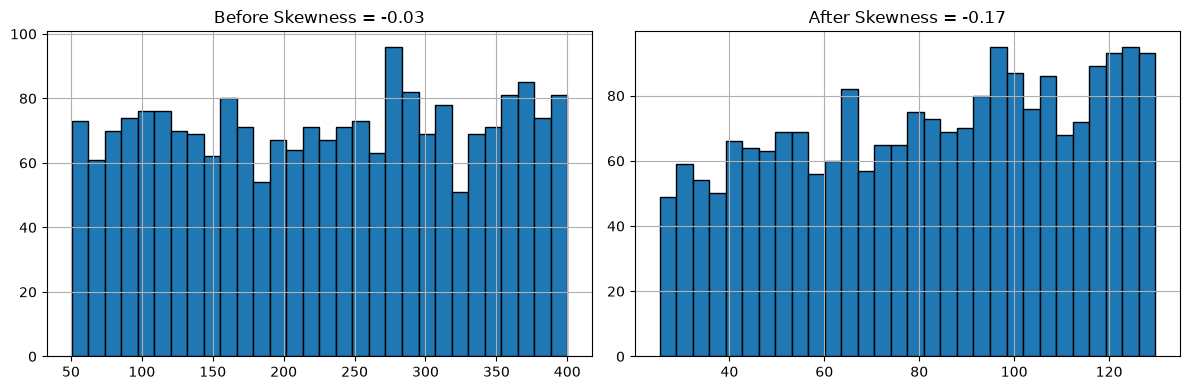

In [56]:
compare_distribution(df, "cholesteroltriglycerides", "cholesteroltriglycerides_boxcox")

### **4.5 Binning / Discretization :** Binning transforms a continuous numerical feature into a set of discrete intervals (bins). Instead of using the exact value, the model receives groups or categories.

Example:
Original Age:

61
68
75
83


After Binning:

60-70
70-80
80-90

### Why use Binning?

Binning can help to:

* Reduce the effect of noise.
* Handle non-linear relationships.
* Make patterns easier to capture.
* Improve interpretability.

### When to use?

Use Binning when:

* The relationship between feature and target is not linear.
* Domain knowledge defines meaningful groups.
* Extreme values create instability.

In [57]:
df["age_group"] = pd.cut(df["age"], bins=[0, 60, 75, 100], labels=["Young", "Middle", "Elderly"], include_lowest=True)
df[["age", "age_group"]]

,age,age_group
0,73,Middle
1,89,Elderly
2,73,Middle
3,74,Middle
4,89,Elderly
...,...,...
2144,61,Middle
2145,75,Middle
2146,77,Elderly
2147,78,Elderly


### **4.6 Equal Frequency Binning :** Equal Frequency Binning divides a numerical feature into bins that contain approximately the same number of observations. Instead of making bins with equal ranges, it uses the distribution of the data.

The data is divided based on quantiles:
Bin boundaries = Quantiles of the feature
Example:

4 bins:

Bin 1 → lowest 25% of values
Bin 2 → 25%-50%
Bin 3 → 50%-75%
Bin 4 → highest 25%

### When to use?

Use Equal Frequency Binning when:

* The feature distribution is highly skewed.
* You want balanced samples in each bin.
* Equal width creates empty or very small bins.

Common examples:

* Age
* Income
* Risk scores
* Medical measurements

In [58]:
df["mmse_group"] = pd.qcut(df["mmse"], q=4, labels=["Low", "Medium_Low", "Medium_High", "High"])
df

,patientid,age,gender,ethnicity,educationlevel,bmi,smoking,alcoholconsumption,physicalactivity,dietquality,sleepquality,familyhistoryalzheimers,cardiovasculardisease,diabetes,depression,headinjury,hypertension,systolicbp,diastolicbp,cholesteroltotal,cholesterolldl,cholesterolhdl,cholesteroltriglycerides,mmse,functionalassessment,memorycomplaints,behavioralproblems,adl,confusion,disorientation,personalitychanges,difficultycompletingtasks,forgetfulness,diagnosis,doctorincharge,doctor_frequency,doctor_target,risk_count,ethnicity_log,bmi_sqrt,physicalactivity_sqrt,cholesteroltriglycerides_boxcox,cholesteroltriglycerides_yeojohnson,age_group,mmse_group
0,4751,73,0,0,2.0,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,XXXConfid,2149,0.353653,2,0.000000,4.788293,2.515375,64.079314,-0.601892,Middle,Medium_High
1,4752,89,0,0,0.0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,XXXConfid,2149,0.353653,0,0.000000,5.179544,2.760414,102.237190,0.672228,Elderly,Medium_High
2,4753,73,0,3,1.0,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,XXXConfid,2149,0.353653,0,1.386294,4.218517,2.800891,37.959671,-1.473047,Middle,Medium_Low
3,4754,74,1,0,1.0,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,XXXConfid,2149,0.353653,1,0.000000,5.813847,2.903102,97.590568,0.517022,Middle,Medium_Low
4,4755,89,0,0,0.0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,XXXConfid,2149,0.353653,0,0.000000,4.551590,2.512063,101.307111,0.641161,Elderly,Medium_Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,6895,61,0,0,1.0,39.121757,0,1.561126,4.049964,6.555306,7.535540,0,0,0,0,0,0,122,101,280.476824,94.870490,60.943092,234.520123,1.201190,0.238667,0,0,4.492838,1,0,0,0,0,1,XXXConfid,2149,0.353653,0,0.000000,6.254739,2.012452,85.551972,0.114967,Middle,Low
2145,6896,75,0,0,2.0,17.857903,0,18.767261,1.360667,2.904662,8.555256,0,0,0,0,0,0,152,106,186.384436,95.410700,93.649735,367.986877,6.458060,8.687480,0,1,9.204952,0,0,0,0,0,1,XXXConfid,2149,0.353653,0,0.000000,4.225861,1.166476,121.572292,1.318162,Middle,Low
2146,6897,77,0,0,1.0,15.476479,0,4.594670,9.886002,8.120025,5.769464,0,0,0,0,0,0,115,118,237.024558,156.267294,99.678209,294.802338,17.011003,1.972137,0,0,5.036334,0,0,0,0,0,1,XXXConfid,2149,0.353653,0,0.000000,3.934016,3.144201,102.283580,0.673778,Elderly,Medium_High
2147,6898,78,1,3,1.0,15.299911,0,8.674505,6.354282,1.263427,8.322874,0,1,0,0,0,0,103,96,242.197192,52.482961,81.281111,145.253746,4.030491,5.173891,0,0,3.785399,0,0,0,0,1,1,XXXConfid,2149,0.353653,1,1.386294,3.911510,2.520770,58.756026,-0.779534,Elderly,Low


### **4.7 Decision Tree Based Binning :** Decision Tree Based Binning uses a decision tree algorithm to find the best split points for a numerical feature based on the target variable. unlike Equal Width and Equal Frequency, the bins are created using the relationship between the feature and the target.

### Concept

The algorithm finds thresholds that maximize the separation between target classes.

Example:

Age

< 68        → Lower risk
68 - 76     → Medium risk
> 76        → Higher risk

The split points are learned from the data.

### When to use?

Use Decision Tree Based Binning when:

* The feature has a non-linear relationship with the target.
* You want bins that are predictive.
* Domain-based thresholds are unknown.

Common examples:

* Age vs Disease Risk
* Blood Pressure vs Outcome
* Medical Scores vs Diagnosis


In [59]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
X = df[["age"]]
y = df["diagnosis"]

tree.fit(X, y)

print(export_text(tree, feature_names=["age"]))

|--- age <= 63.50
|   |--- age <= 60.50
|   |   |--- class: 0
|   |--- age >  60.50
|   |   |--- age <= 61.50
|   |   |   |--- class: 0
|   |   |--- age >  61.50
|   |   |   |--- class: 0
|--- age >  63.50
|   |--- age <= 82.50
|   |   |--- age <= 81.50
|   |   |   |--- class: 0
|   |   |--- age >  81.50
|   |   |   |--- class: 0
|   |--- age >  82.50
|   |   |--- age <= 84.50
|   |   |   |--- class: 0
|   |   |--- age >  84.50
|   |   |   |--- class: 0



# **5. Handling Outliers** Outliers are observations that are significantly different from the majority of the data.

They can be:

* **Errors** → incorrect measurements, data entry mistakes, sensor problems.
* **Meaningful extreme values** → real but rare cases that contain important information.

The goal is not always to remove outliers, but to understand their impact and choose an appropriate treatment.


## Why Handle Outliers?

Outliers can:

* Distort mean and standard deviation.
* Affect distance-based models.
* Reduce model performance.
* Influence linear regression coefficients.

However, removing meaningful extreme values may remove important information.


# Detection Methods

Common methods:

* IQR Method
* Z-score Method
* Isolation Forest
* Visual Methods


# Treatment Methods

Common approaches:

* Capping / Winsorizing
* Transformation
* Removal (carefully)
* Using Robust Models or Scalers


# Important Decision

Before treating outliers, ask:

Is this value:

1. A data error?

   * Remove or correct it.

2. A meaningful extreme case?

   * Keep it or use robust methods.


## **5.1 IQR Method (Interquartile Range) :** IQR method detects outliers based on the spread of the middle 50% of the data. It uses the distance between the first quartile (Q1) and third quartile (Q3).

```text
IQR = Q3 - Q1
```

Lower boundary:

```text
Lower Bound = Q1 - 1.5 × IQR
```

Upper boundary:

```text
Upper Bound = Q3 + 1.5 × IQR
```

Values outside these boundaries are considered outliers.

### When to use?

Use IQR when:

* The data is not normally distributed.
* The dataset contains skewed features.
* You want a robust method.

In [60]:
outlier_summary = {}

for col in continuous_numeric_columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary[col] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier Percentage": (len(outliers) / len(df)) * 100
    }
outlier_df = pd.DataFrame(outlier_summary).T
outlier_df

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
patientid,5288.000000,6362.000000,1074.000000,3677.000000,7973.000000,0.0,0.0
age,67.000000,83.000000,16.000000,43.000000,107.000000,0.0,0.0
bmi,21.611408,33.869778,12.258370,3.223853,52.257332,0.0,0.0
alcoholconsumption,5.139810,15.157931,10.018121,-9.887372,30.185112,0.0,0.0
physicalactivity,2.570626,7.427899,4.857272,-4.715282,14.713807,0.0,0.0
dietquality,2.458455,7.558625,5.100170,-5.191800,15.208879,0.0,0.0
sleepquality,5.482997,8.562521,3.079524,0.863712,13.181807,0.0,0.0
systolicbp,112.000000,157.000000,45.000000,44.500000,224.500000,0.0,0.0
diastolicbp,74.000000,105.000000,31.000000,27.500000,151.500000,0.0,0.0
cholesteroltotal,190.252963,262.031657,71.778693,82.584923,369.699697,0.0,0.0


## **5.2 Z-score Method :** Z-score measures how far a data point is from the mean in terms of standard deviations. It identifies observations that are unusually far from the average value.


```text
z = (x - μ) / σ
```

Where:

* `x` = original value
* `μ` = mean of the feature
* `σ` = standard deviation of the feature

### Outlier Rule

Commonly:

```text
|z| > 3
```

is considered an outlier.

This means the value is more than 3 standard deviations away from the mean.

### When to use?

Use Z-score when:

* The feature distribution is approximately normal.
* Mean and standard deviation are meaningful.
* Extreme values are expected to be rare.

In [61]:
zscore_summary = {}

for col in continuous_numeric_columns:

    mean = df[col].mean()
    std = df[col].std()
    z_scores = (df[col] - mean) / std
    outliers = df[np.abs(z_scores) > 3]

    zscore_summary[col] = {
        "Mean": mean,
        "Std": std,
        "Outlier Count": len(outliers),
        "Outlier Percentage": (
            len(outliers) / len(df)
        ) * 100
    }

zscore_df = pd.DataFrame(zscore_summary).T
zscore_df

,Mean,Std,Outlier Count,Outlier Percentage
patientid,5825.000000,620.507185,0.0,0.0
age,74.908795,8.990221,0.0,0.0
bmi,27.655697,7.217438,0.0,0.0
alcoholconsumption,10.039442,5.757910,0.0,0.0
physicalactivity,4.920202,2.857191,0.0,0.0
dietquality,4.993138,2.909055,0.0,0.0
sleepquality,7.051081,1.763573,0.0,0.0
systolicbp,134.264774,25.949352,0.0,0.0
diastolicbp,89.847836,17.592496,0.0,0.0
cholesteroltotal,225.197519,42.542233,0.0,0.0


### **5.3 Isolation Forest :** Isolation Forest is a machine learning based method for detecting outliers. Instead of looking at each feature independently, it analyzes observations based on combinations of features.
The idea is that outliers are:
* Rare.
* Different from normal observations.
* Easier to isolate using random splits.


Isolation Forest builds multiple random decision trees. Observations that require fewer splits to isolate are considered more likely to be outliers.

The model assigns an anomaly score:

```text id="2u8q3m"
Lower score → More likely outlier
Higher score → More normal
```

### When to use?

Use Isolation Forest when:

* You have many numerical features.
* Outliers depend on multiple variables.
* Simple univariate methods are not enough.

Examples:

* Fraud detection.
* Medical anomaly detection.
* Sensor monitoring.

In [62]:

X = df[continuous_numeric_columns]
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_prediction = iso_forest.fit_predict(X)
outlier_prediction

array([1, 1, 1, ..., 1, 1, 1], shape=(2149,))

In [63]:
df["outlier_flag"] = outlier_prediction
df.head()

,patientid,age,gender,ethnicity,educationlevel,bmi,smoking,alcoholconsumption,physicalactivity,dietquality,sleepquality,familyhistoryalzheimers,cardiovasculardisease,diabetes,depression,headinjury,hypertension,systolicbp,diastolicbp,cholesteroltotal,cholesterolldl,cholesterolhdl,cholesteroltriglycerides,mmse,functionalassessment,memorycomplaints,behavioralproblems,adl,confusion,disorientation,personalitychanges,difficultycompletingtasks,forgetfulness,diagnosis,doctorincharge,doctor_frequency,doctor_target,risk_count,ethnicity_log,bmi_sqrt,physicalactivity_sqrt,cholesteroltriglycerides_boxcox,cholesteroltriglycerides_yeojohnson,age_group,mmse_group,outlier_flag
0,4751,73,0,0,2.0,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,XXXConfid,2149,0.353653,2,0.000000,4.788293,2.515375,64.079314,-0.601892,Middle,Medium_High,1
1,4752,89,0,0,0.0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,XXXConfid,2149,0.353653,0,0.000000,5.179544,2.760414,102.237190,0.672228,Elderly,Medium_High,1
2,4753,73,0,3,1.0,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,XXXConfid,2149,0.353653,0,1.386294,4.218517,2.800891,37.959671,-1.473047,Middle,Medium_Low,1
3,4754,74,1,0,1.0,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,XXXConfid,2149,0.353653,1,0.000000,5.813847,2.903102,97.590568,0.517022,Middle,Medium_Low,1
4,4755,89,0,0,0.0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,XXXConfid,2149,0.353653,0,0.000000,4.551590,2.512063,101.307111,0.641161,Elderly,Medium_Low,1


In [64]:
outliers = df[df["outlier_flag"] == -1]
outliers

,patientid,age,gender,ethnicity,educationlevel,bmi,smoking,alcoholconsumption,physicalactivity,dietquality,sleepquality,familyhistoryalzheimers,cardiovasculardisease,diabetes,depression,headinjury,hypertension,systolicbp,diastolicbp,cholesteroltotal,cholesterolldl,cholesterolhdl,cholesteroltriglycerides,mmse,functionalassessment,memorycomplaints,behavioralproblems,adl,confusion,disorientation,personalitychanges,difficultycompletingtasks,forgetfulness,diagnosis,doctorincharge,doctor_frequency,doctor_target,risk_count,ethnicity_log,bmi_sqrt,physicalactivity_sqrt,cholesteroltriglycerides_boxcox,cholesteroltriglycerides_yeojohnson,age_group,mmse_group,outlier_flag
5,4756,86,1,1,1.0,30.626886,0,4.140144,0.211062,1.584922,7.261953,0,0,1,0,0,0,168,62,280.712539,198.334629,79.080503,263.943655,27.517529,5.510144,0,0,9.015686,1,0,0,0,0,0,XXXConfid,2149,0.353653,1,0.693147,5.534156,0.459414,93.828435,0.391368,Elderly,High,-1
25,4776,77,0,1,0.0,39.123677,0,0.953869,8.939249,0.043147,9.582177,1,0,1,0,0,0,115,112,299.868482,88.110915,81.983039,279.759026,24.598559,7.710189,0,0,6.286606,1,0,1,0,0,0,XXXConfid,2149,0.353653,1,0.693147,6.254892,2.989858,98.188597,0.536997,Elderly,High,-1
43,4794,66,0,0,1.0,37.568530,0,2.218580,2.915573,9.750511,9.741159,0,0,0,0,0,0,93,64,274.406455,54.459924,35.594067,338.581129,14.421212,2.193044,0,0,2.856806,0,0,0,0,0,1,XXXConfid,2149,0.353653,0,0.000000,6.129317,1.707505,113.938938,1.063134,Middle,Medium_Low,-1
53,4804,61,1,2,0.0,38.076135,0,19.984018,9.859542,1.915171,9.710274,0,0,1,0,0,1,98,116,215.421298,159.510702,92.800096,59.925622,20.352169,2.095929,1,0,9.456373,0,0,0,0,0,1,XXXConfid,2149,0.353653,2,1.098612,6.170586,3.139991,29.069884,-1.769107,Middle,Medium_High,-1
59,4810,68,0,0,3.0,36.496388,1,3.292011,9.673810,7.788819,7.621481,0,1,0,0,0,0,164,79,190.330529,178.396268,74.274119,61.984416,14.813436,8.964178,0,0,1.015526,0,1,0,0,0,0,XXXConfid,2149,0.353653,2,0.000000,6.041224,3.110275,29.870249,-1.742468,Middle,Medium_High,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,6867,87,1,0,1.0,30.415737,0,6.317087,2.302766,2.982930,4.249376,0,0,0,0,0,0,90,111,220.161313,80.172458,21.356942,366.580729,25.741795,2.373504,0,0,5.247041,0,0,1,0,0,0,XXXConfid,2149,0.353653,0,0.000000,5.515046,1.517487,121.210550,1.306076,Elderly,High,-1
2121,6872,61,0,0,3.0,25.532212,0,4.226343,2.800972,4.219056,4.510746,0,0,1,0,1,0,92,116,157.721993,166.364884,62.368115,51.064227,1.376810,8.344547,0,0,2.698306,0,0,0,0,0,1,XXXConfid,2149,0.353653,1,0.000000,5.052941,1.673610,25.548843,-1.886253,Middle,Low,-1
2127,6878,89,1,2,1.0,35.806100,1,13.076450,6.523344,8.591301,6.069556,0,0,0,0,0,0,164,109,272.546497,157.437722,80.042108,367.318742,4.494166,1.411929,0,0,1.476536,0,0,0,0,0,0,XXXConfid,2149,0.353653,1,1.098612,5.983820,2.554084,121.400449,1.312421,Elderly,Low,-1
2132,6883,65,1,0,1.0,18.517832,0,8.264128,5.235068,8.456602,6.681213,0,0,1,0,0,0,94,117,281.026862,83.219329,95.845046,61.028894,5.727075,2.269810,0,1,9.106985,0,0,0,0,0,1,XXXConfid,2149,0.353653,1,0.000000,4.303235,2.288027,29.499558,-1.754807,Middle,Low,-1


### **6. Dimensionality Reduction :** Dimensionality Reduction is the process of reducing the number of input features while preserving as much useful information as possible. instead of using all original features, the data is represented using a smaller set of new variables. These new variables are called **components** or **latent features**, depending on the method.


## Why use Dimensionality Reduction?

High-dimensional datasets often suffer from several problems:

* Increased computational cost.
* Higher memory usage.
* Risk of overfitting.
* Multicollinearity.
* Difficulty in visualization.

Reducing the number of features can improve model efficiency while retaining most of the important information.-

## Two Main Categories

### Linear Methods

Assume that the data lies on a linear subspace.

* Principal Component Analysis (PCA)
* Linear Discriminant Analysis (LDA)
* Factor Analysis (FA)


### Non-linear Methods

Capture complex relationships that cannot be represented by linear combinations.

* t-SNE
* UMAP
* Autoencoders


### **6.1 Principal Component Analysis (PCA) :** Principal Component Analysis (PCA) is an unsupervised linear dimensionality reduction technique that transforms the original features into a new set of uncorrelated variables called **Principal Components (PCs)**. Instead of selecting existing features, PCA creates new features that are linear combinations of the original ones.

### **Main Idea**

Many datasets contain highly correlated features.

PCA combines these correlated features into a smaller number of components while preserving as much information (variance) as possible.

The first component captures the maximum possible variance.

Each subsequent component captures the maximum remaining variance while being orthogonal to all previous components.


### **Mathematical Representation**

Assume the dataset contains **p** features.

PCA creates new variables:

```text
PC₁ = w₁₁x₁ + w₁₂x₂ + ... + w₁ₚxₚ

PC₂ = w₂₁x₁ + w₂₂x₂ + ... + w₂ₚxₚ

...

PCₖ = wₖ₁x₁ + wₖ₂x₂ + ... + wₖₚxₚ
```

where

* **x** = original features
* **w** = component weights (loadings)


Find directions that maximize variance.

Mathematically,

```text
Maximize

Var(Xw)
```

subject to

```text
||w|| = 1
```

The first component maximizes the variance.

The second component also maximizes variance but must be perpendicular (orthogonal) to the first.


PCA computes the covariance matrix

```text
Σ
```

Then solves

```text
Σv = λv
```

where

* λ = eigenvalue
* v = eigenvector

Each eigenvector becomes one Principal Component.

Each eigenvalue measures how much variance that component explains.



For component i

```text
Explained Variance Ratio

= λᵢ / Σλ
```

This tells us how much information is preserved by that component.



Features often have different scales.

Example

```text
Age            60–90

BMI            15–40

Cholesterol    150–350
```

Without scaling, Cholesterol would dominate the covariance matrix.

Therefore PCA is usually applied after **StandardScaler**.


In [65]:
X = df.drop(columns=["diagnosis", "patientid", "doctorincharge", "age_group", "mmse_group"])
y = df["diagnosis"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [66]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
X_pca.shape

(2149, 31)

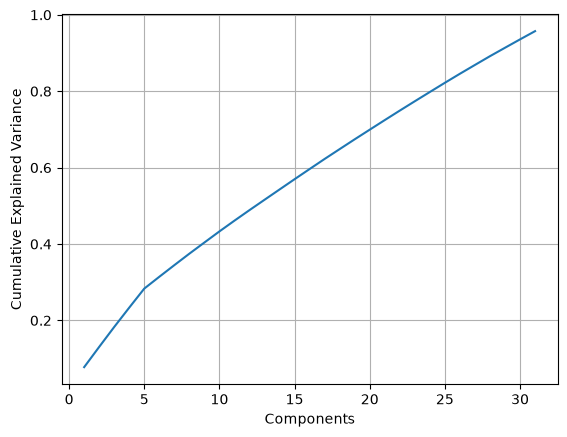

In [67]:
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_.cumsum())
plt.xlabel("Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.show()

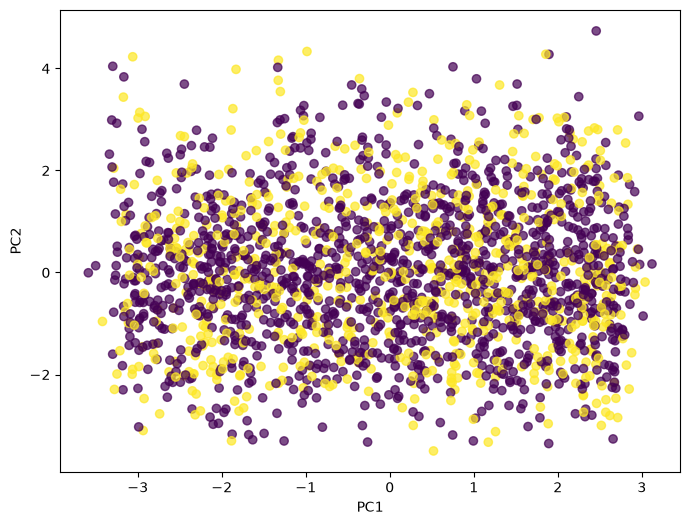

In [68]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=y, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

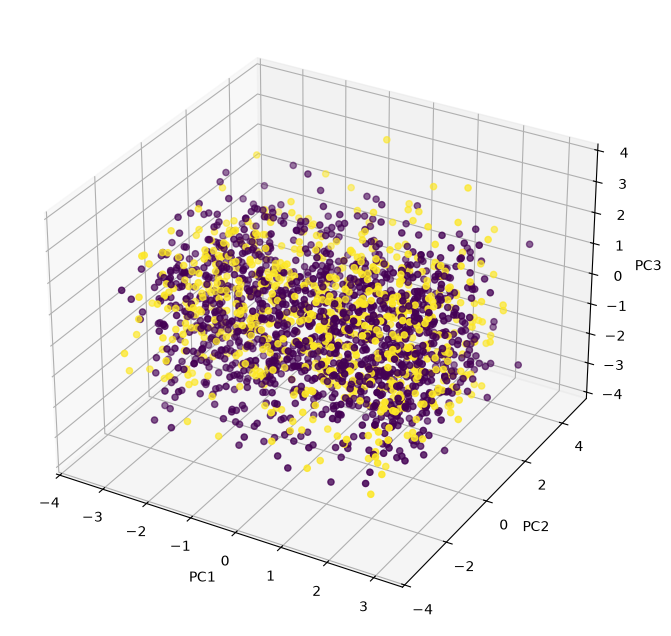

In [69]:

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca_3d[:,0], X_pca_3d[:,1], X_pca_3d[:,2], c=y)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()

In [70]:
pca_3d.explained_variance_ratio_

array([0.07763369, 0.05305174, 0.05219653])

In [71]:

ica = FastICA(n_components=3, random_state=42, max_iter=1000)
X_ica = ica.fit_transform(X_scaled)
X_ica.shape

(2149, 3)

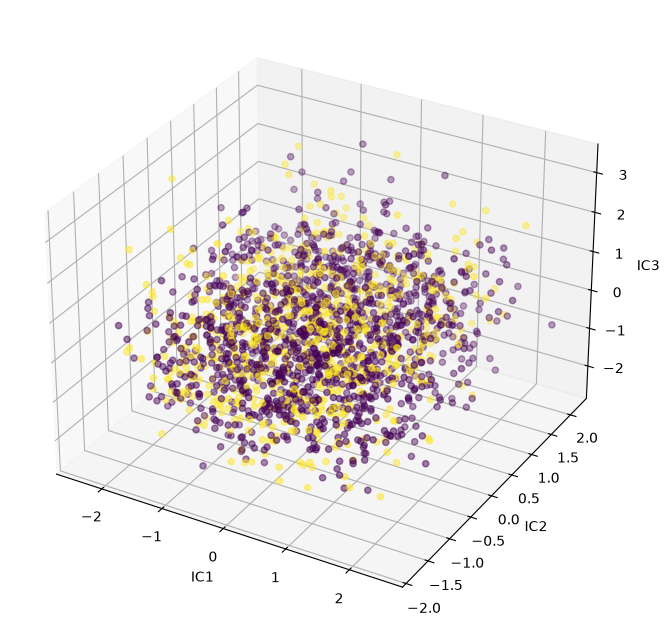

[[ 2.15044067e-02 -2.08208401e-03  1.23283295e-01  2.86770554e-02
  -4.62204473e-01 -4.36624431e-02  8.57652690e-03 -6.24577067e-02
  -1.93551883e-02  1.29410926e-02  8.30133590e-03 -2.29632787e-02
  -2.13917383e-02 -1.69858574e-02 -1.89487972e-02 -3.12881651e-02
   1.63891949e-02  1.07725902e-02 -3.60465248e-03 -2.04821696e-02
  -3.83621403e-02  5.44678583e-03 -1.48458348e-03  3.09893688e-02
  -2.65675899e-02 -3.49307625e-02  1.81681069e-02  2.02984077e-02
   2.74407888e-02  1.32303276e-02  3.90850637e-02 -7.74980698e-02
   6.37661971e-38 -2.14265461e-38 -6.27205443e-02  1.25144261e-01
  -4.62081262e-01 -6.29588035e-02  5.29834909e-03  5.30033382e-03
   1.36832899e-02]
 [ 2.11303265e-03  6.81171706e-03  9.82756851e-03  1.35355167e-02
  -2.96241867e-03  8.29054448e-03 -1.33749705e-02 -3.26664479e-02
  -1.71911290e-02 -1.11208199e-02 -5.89939021e-05  1.77224695e-04
   1.96891855e-02 -2.17636005e-02 -9.09332525e-03  3.13710180e-03
   1.75118871e-02  3.66743591e-03  5.09475366e-04  2.7379

In [72]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_ica[:,0], X_ica[:,1], X_ica[:,2], c=y, alpha=0.8)
ax.set_xlabel("IC1")
ax.set_ylabel("IC2")
ax.set_zlabel("IC3")
plt.show()
print(ica.components_)

In [73]:

isomap = Isomap(n_components=2, n_neighbors=10)
X_isomap = isomap.fit_transform(X_scaled)
X_isomap.shape

d:\data-analysis-notes\data-analysis-notes\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\data-analysis-notes\data-analysis-notes\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "d:\data-analysis-notes\data-analysis-notes\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Python314\Lib\subprocess.py", line 554, in run
    with Popen(*po

(2149, 2)

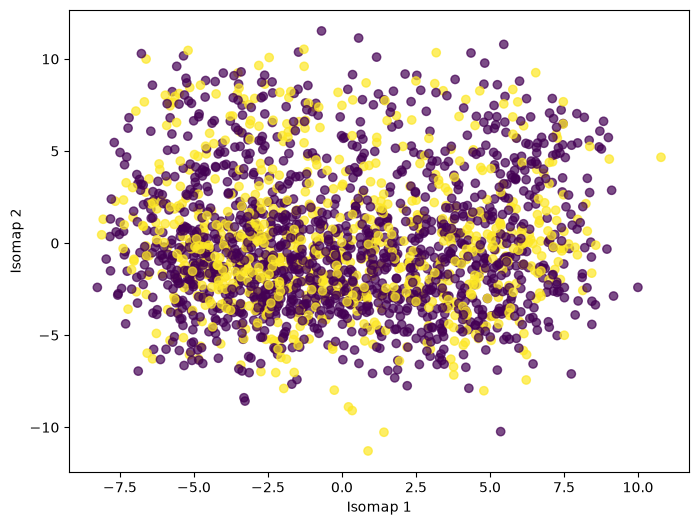

In [74]:
plt.figure(figsize=(8,6))

plt.scatter(X_isomap[:,0], X_isomap[:,1], c=y, alpha=0.7)
plt.xlabel("Isomap 1")
plt.ylabel("Isomap 2")
plt.show()

In [75]:
pca = PCA()

X_pca = pca.fit_transform(X_standard)
print(X_pca.shape)

explained_variance = pca.explained_variance_ratio_
print(explained_variance)

(2149, 16)
[0.06989157 0.069189   0.06714412 0.06660066 0.06627182 0.06463775
 0.06378853 0.06302894 0.06260863 0.06139017 0.05967908 0.0593989
 0.05814644 0.05731417 0.05599993 0.0549103 ]


In [76]:
variance_df = pd.DataFrame({
    "Component": range(1, len(explained_variance)+1),
    "Explained Variance": explained_variance,
    "Cumulative Variance": explained_variance.cumsum()
})
variance_df

,Component,Explained Variance,Cumulative Variance
0,1,0.069892,0.069892
1,2,0.069189,0.139081
2,3,0.067144,0.206225
3,4,0.066601,0.272825
4,5,0.066272,0.339097
5,6,0.064638,0.403735
6,7,0.063789,0.467523
7,8,0.063029,0.530552
8,9,0.062609,0.593161
9,10,0.061390,0.654551


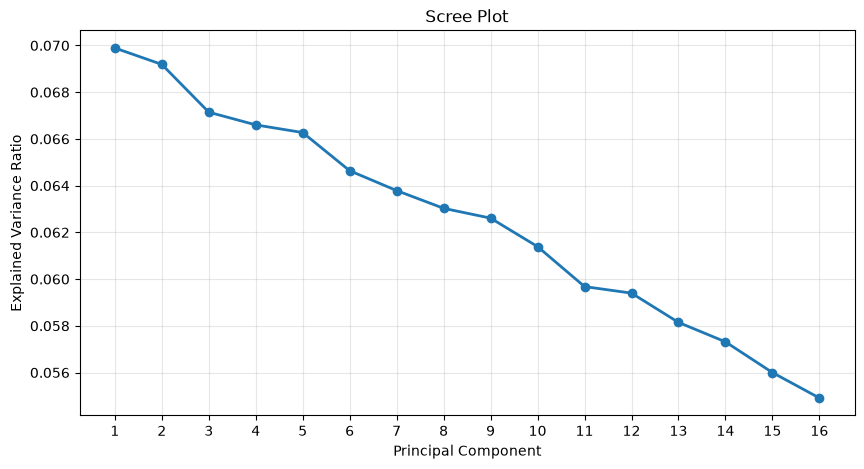

In [77]:
plt.figure(figsize=(10,5))
plt.plot(variance_df["Component"], variance_df["Explained Variance"], marker="o", linewidth=2)
plt.xticks(variance_df["Component"])
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(alpha=0.3)
plt.show()

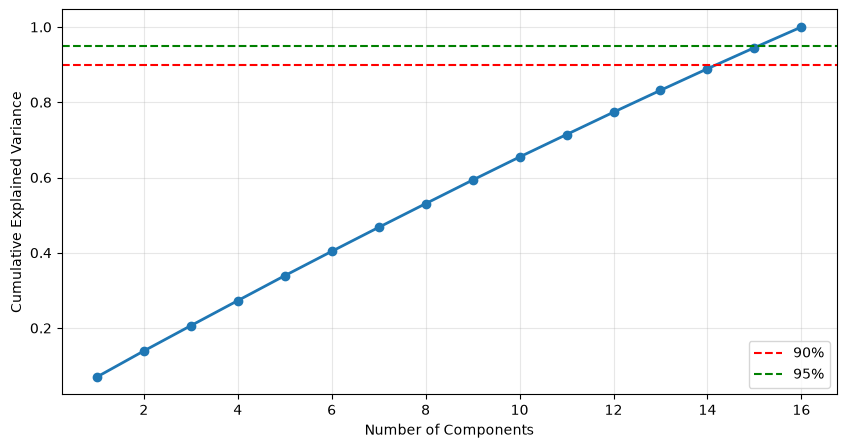

In [78]:
plt.figure(figsize=(10,5))
plt.plot(variance_df["Component"], variance_df["Cumulative Variance"], marker="o", linewidth=2)
plt.axhline(y=0.90, color="red", linestyle="--", label="90%")
plt.axhline(y=0.95, color="green", linestyle="--", label="95%")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [79]:
for i, v in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {v:.3f}")

PC1: 0.070
PC2: 0.069
PC3: 0.067
PC4: 0.067
PC5: 0.066
PC6: 0.065
PC7: 0.064
PC8: 0.063
PC9: 0.063
PC10: 0.061
PC11: 0.060
PC12: 0.059
PC13: 0.058
PC14: 0.057
PC15: 0.056
PC16: 0.055


In [80]:
# PCA with 3 components
pca_3d = PCA(n_components=3)

X_pca_3d = pca_3d.fit_transform(X_standard)

# Create dataframe
pca_3d_df = pd.DataFrame(X_pca_3d, columns=["PC1", "PC2", "PC3"])

# Add target for coloring
pca_3d_df["diagnosis"] = df["diagnosis"].values


print("Explained variance:", pca_3d.explained_variance_ratio_)

print("Total variance:", pca_3d.explained_variance_ratio_.sum())

Explained variance: [0.06989157 0.069189   0.06714412]
Total variance: 0.20622469439223545


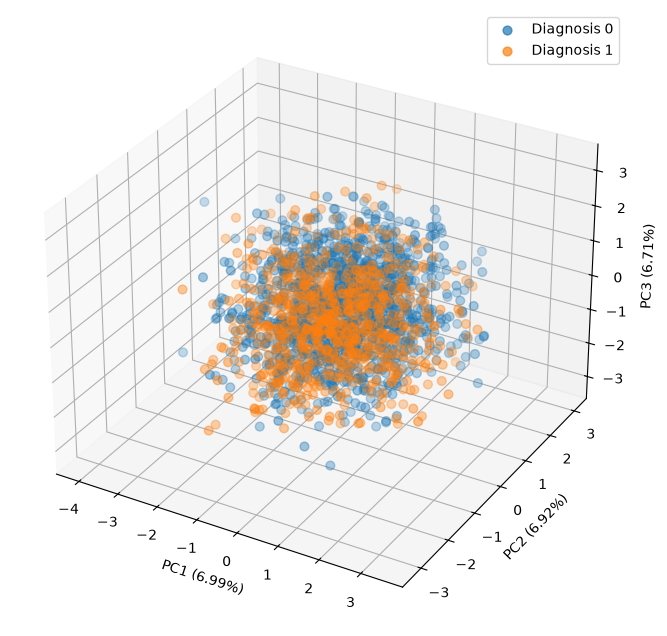

In [81]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
for label in sorted(pca_3d_df["diagnosis"].unique()):
    subset = pca_3d_df[pca_3d_df["diagnosis"] == label]
    ax.scatter(subset["PC1"], subset["PC2"], subset["PC3"], s=40, alpha=0.7, label=f"Diagnosis {label}")
ax.set_xlabel(f"PC1 ({pca_3d.explained_variance_ratio_[0]*100:.2f}%)")
ax.set_ylabel(f"PC2 ({pca_3d.explained_variance_ratio_[1]*100:.2f}%)")
ax.set_zlabel(f"PC3 ({pca_3d.explained_variance_ratio_[2]*100:.2f}%)")
ax.legend()
plt.show()

In [82]:

lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_standard, df["diagnosis"])
X_lda.shape

(2149, 1)

In [83]:
lda_df = pd.DataFrame(X_lda, columns=["LD1"])
lda_df["diagnosis"] = df["diagnosis"].values
lda_df.head()

,LD1,diagnosis
0,-0.343087,0
1,-0.536124,0
2,-0.725421,0
3,-1.314188,0
4,0.868961,0


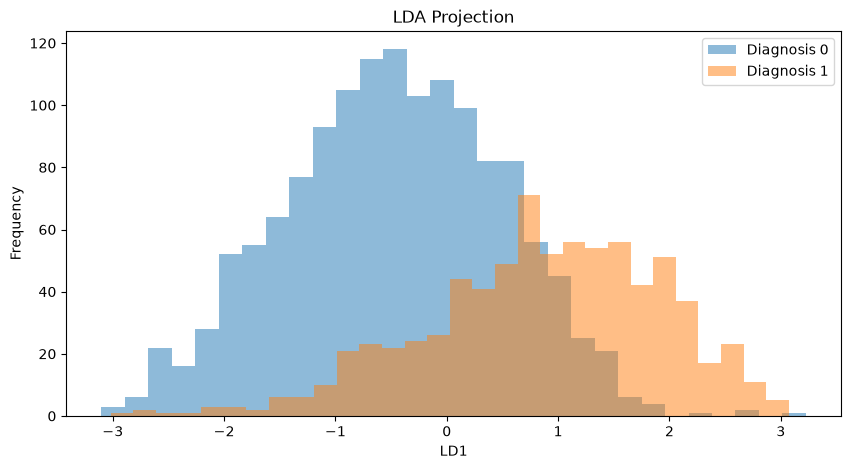

In [84]:
plt.figure(figsize=(10,5))


for label in sorted(lda_df["diagnosis"].unique()):
    subset = lda_df[lda_df["diagnosis"] == label]
    plt.hist(subset["LD1"], bins=30, alpha=0.5, label=f"Diagnosis {label}")
plt.xlabel("LD1")
plt.ylabel("Frequency")
plt.title("LDA Projection")
plt.legend()
plt.show()

In [85]:

fa = FactorAnalysis(n_components=5, random_state=42)
X_fa = fa.fit_transform(X_standard)
print(X_fa.shape)

fa_df = pd.DataFrame(X_fa, columns=[f"Factor_{i+1}" for i in range(5)])
fa_df.head()

(2149, 5)


,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5
0,0.165500,0.001886,-0.207003,-0.042156,0.113806
1,-0.057003,-0.317116,-0.641752,0.321347,0.151861
2,0.438166,-0.189596,-0.177194,0.194223,0.121155
3,0.786793,-0.254427,0.527310,0.101889,-0.046160
4,-0.073804,-0.439805,-0.354303,-0.553221,0.005796
